# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

## <div class="alert alert-info"> <b> Введение в проект </b> </div>

В этом проекте решается задача прогнозирования оттока клиентов сервиса доставки кофе компании **Happy Beans Coffee**.  
Компания столкнулась с высокой ежемесячной потерей клиентов, что снижает выручку и делает маркетинговые расходы менее эффективными. Поскольку удержание существующего клиента обходится дешевле, чем привлечение нового, бизнесу важно заранее понимать, кто из покупателей может отказаться от сервиса в ближайший месяц.

Цель проекта — построить модель **бинарной классификации**, которая для каждого клиента будет определять один из двух статусов:
- **клиент лояльный**;
- **клиент может уйти**.

В качестве исходных данных используется датасет с признаками, описывающими клиентов и их поведение. На основе этих данных необходимо обучить модель, способную оценивать вероятность оттока в следующем месяце.

С практической точки зрения результаты такого анализа помогут компании:
- точечно работать с клиентами, которые находятся в зоне риска;
- эффективнее распределять маркетинговый бюджет;
- лучше прогнозировать будущую выручку и устойчивость клиентской базы.

С учётом бизнес-постановки задача требует не только обнаруживать клиентов, склонных к уходу, но и делать это достаточно точно, чтобы не тратить ресурсы на лишние удерживающие меры. Поэтому при оценке качества модели особое внимание будет уделено метрикам, связанным с балансом **Precision** и **Recall**. В качестве основной метрики качества будет рассматриваться **PR AUC**, а также дополнительно будут анализироваться **Precision**, **Recall** и **F1-score**.

В ходе проекта планируется:
1. изучить структуру данных и выполнить первичный анализ;
2. провести предобработку признаков и обработать пропуски;
3. подготовить выборки для обучения и тестирования;
4. обучить базовую и основную модели классификации;
5. оценить качество модели с помощью кросс-валидации;
6. подобрать оптимальные параметры модели;
7. проанализировать итоговые результаты и подготовить модель к сохранению для дальнейшего использования.

Таким образом, итогом проекта станет интерпретируемая модель прогнозирования оттока клиентов, которую можно использовать как основу для принятия бизнес-решений по удержанию пользователей сервиса.

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, precision_recall_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV

import joblib
from pathlib import Path

RANDOM_STATE = 42
N_FOLDS = 5

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Хорошо, что все импорты в одной ячейке

In [2]:
%%writefile requirements.txt
# Tested with Python 3.14.3
numpy==2.3.5
pandas==2.2.3
scipy==1.17.0
scikit-learn==1.8.0
matplotlib==3.10.8
seaborn==0.13.2
joblib==1.5.3

Overwriting requirements.txt


In [3]:
df = pd.read_csv('coffee_churn_dataset.csv', sep=',', decimal='.')

#df = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

In [4]:
df.info()

display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [5]:
# 1. Описываем данные

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print(f'Количество полных дубликатов: {df.duplicated().sum()}')
print(f'Количество дубликатов user_id: {df["user_id"].duplicated().sum()}')

overview = pd.DataFrame({
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(dropna=True)
}).sort_values('missing', ascending=False)

display(overview)

Размер датасета: 10450 строк, 27 столбцов
Количество полных дубликатов: 0
Количество дубликатов user_id: 0


,missing,missing_pct,nunique
seasonal_menu_tried,989,9.46,2
days_since_last_order,945,9.04,39
total_spent_last_week,944,9.03,9090
subscription_status,938,8.98,4
app_opens_per_week,896,8.57,9065
review_rating_last_1,857,8.20,9182
median_order_value,831,7.95,9201
days_since_last_promo,731,7.00,106
app_crashes_last_month,721,6.90,8
review_rating_last_10,693,6.63,9328


### Вывод по данным

В датасете **10 450 строк** и **27 столбцов**.  
Каждая строка соответствует **одному уникальному клиенту**, полных дубликатов и повторов `user_id` нет.

Структура данных:
- **1 целевая переменная** — `churn`;
- **1 технический идентификатор** — `user_id`;
- остальные признаки описывают:
  - активность клиента,
  - частоту заказов,
  - траты,
  - использование скидок,
  - вкусовые предпочтения,
  - поведение в приложении,
  - оценки заказов,
  - техническое качество приложения,
  - подписку и регион.

В данных есть и **числовые**, и **категориальные** признаки.  
Также присутствуют **пропуски** почти во всех признаках, поэтому на следующих этапах понадобится их обработка.

По описанию датасета видно, что признаки агрегированы по клиентам и отражают их поведение за последние недели; целевая переменная `churn` показывает факт ухода клиента. 

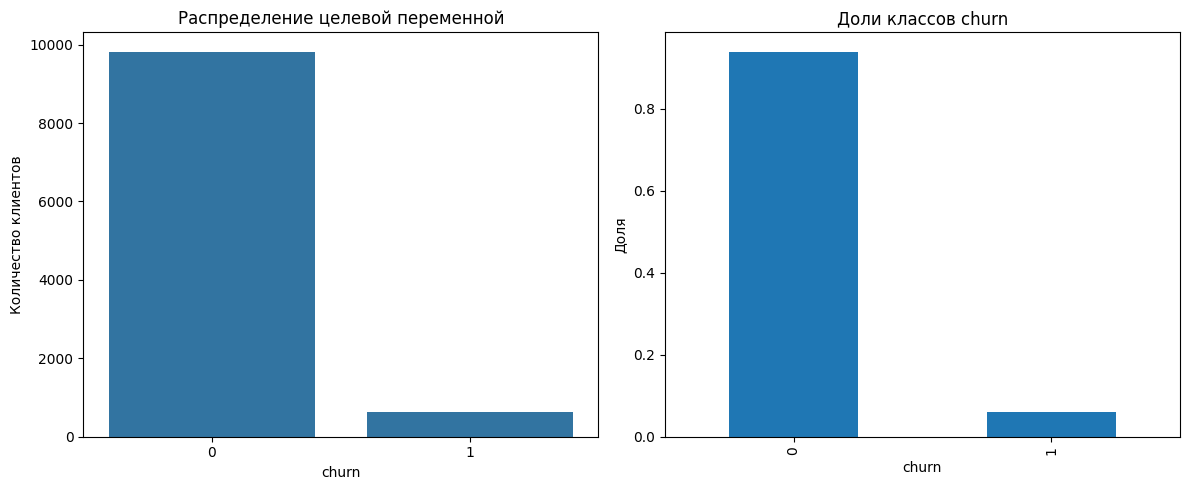

,churn,count,share_pct
0,0,9821,93.98
1,1,629,6.02


In [6]:
# 2. Целевая переменная

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='churn', ax=axes[0])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('churn')
axes[0].set_ylabel('Количество клиентов')

df['churn'].value_counts(normalize=True).sort_index().plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Доли классов churn')
axes[1].set_xlabel('churn')
axes[1].set_ylabel('Доля')

plt.tight_layout()
plt.show()

target_dist = (
    df['churn']
    .value_counts()
    .sort_index()
    .rename_axis('churn')
    .reset_index(name='count')
)

target_dist['share_pct'] = ((target_dist['count'] / len(df)) * 100).round(2)

display(target_dist.sort_values('churn'))

### Вывод по целевой переменной

Целевая переменная `churn` — **бинарная**:
- `0` — клиент остался;
- `1` — клиент ушёл.

Распределение классов **несбалансированное**:
- класс `0`: **9 821 клиентов** (**93.98%**),
- класс `1`: **629 клиентов** (**6.02%**).

Следовательно, в задаче наблюдается выраженный **дисбаланс классов**.  
Это важно учитывать при обучении и оценке модели:
- при разбиении данных лучше использовать **стратификацию**;
- при кросс-валидации — **StratifiedKFold**;
- в качестве основных метрик стоит ориентироваться прежде всего на **PR AUC**.

Accuracy в такой задаче может быть завышенной даже у слабой модели, потому что большинство клиентов не уходит.

In [7]:
# 3. Смотрим признаки и удаляем 'user_id'

df = df.drop(columns='user_id')

TARGET = 'churn'


### Вывод по признакам

Признаки в датасете можно разделить на несколько смысловых групп.

#### 1. Технический признак
- `user_id` — уникальный идентификатор пользователя.

Этот признак нужен только для идентификации строки и не несёт полезной информации для прогноза поведения клиента.

---

#### 2. Поведенческие и транзакционные признаки
- `days_since_last_order` — сколько дней прошло с последнего заказа;
- `order_frequency_month` — среднее число заказов клиента в месяц;
- `order_frequency_week` — среднее число заказов клиента в неделю;
- `avg_order_value` — средний чек клиента;
- `median_order_value` — медианный чек клиента;
- `total_spent_last_month` — общая сумма заказов за последний месяц;
- `total_spent_last_week` — общая сумма заказов за последнюю неделю;
- `discount_usage_rate` — доля заказов, сделанных со скидкой;
- `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.

Эти признаки напрямую описывают покупательскую активность клиента: как часто он заказывает, сколько тратит и насколько давно проявлял активность. Для задачи оттока они потенциально очень важны, потому что снижение частоты заказов, уменьшение трат и длинный перерыв с последней покупки могут сигнализировать о риске ухода.

---

#### 3. Признаки вкусов и предпочтений
- `last_coffee_type` — какой сорт кофе клиент покупал в последний раз;
- `preferred_roast` — предпочитаемый тип обжарки;
- `milk_preference` — предпочитаемый тип молока;
- `coffee_bean_origin` — страна происхождения зерна, которое предпочитает клиент;
- `last_drink_size` — размер последнего заказанного напитка;
- `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.

Эти признаки отражают потребительские привычки клиента. Они могут быть полезны, потому что устойчивые предпочтения часто связаны с более высокой вовлечённостью, а изменение привычек может косвенно указывать на изменение поведения клиента.

---

#### 4. Признаки взаимодействия с сервисом
- `seasonal_menu_tried` — пробовал ли клиент новое сезонное меню;
- `subscription_status` — тип подписки пользователя;
- `app_opens_per_week` — сколько раз в неделю клиент в среднем открывает приложение;
- `notifications_enabled` — включены ли у клиента уведомления;
- `phone_type` — тип устройства, с которого клиент чаще всего оформляет заказы.

Эти признаки показывают, насколько активно клиент взаимодействует именно с сервисом доставки, а не только совершает покупки. Например, частые открытия приложения, включённые уведомления или наличие подписки могут говорить о большей вовлечённости и, возможно, меньшем риске ухода.

---

#### 5. Признаки клиентского опыта
- `review_rating_last_10` — средняя оценка последних десяти заказов;
- `review_rating_last_1` — оценка последнего заказа;
- `app_crashes_last_month` — сколько раз приложение зависало за последний месяц.

Это важная группа признаков, потому что качество клиентского опыта напрямую связано с оттоком. Низкие оценки заказов и частые сбои приложения могут повышать вероятность ухода клиента.

---

#### 6. Контекстные признаки
- `seasons` — текущее время года;
- `geo_location` — идентификатор или категория региона пользователя.

Эти признаки описывают внешний контекст. Сезон и регион могут влиять на частоту заказов, вкусы клиентов и поведение в сервисе, поэтому их тоже стоит сохранить.

---

### Какие признаки можно удалить

На текущем этапе однозначно можно удалить только:
- `user_id` — это технический идентификатор, который не помогает предсказывать отток и не имеет бизнес-смысла для модели.

### Какие признаки пока лучше оставить

Некоторые признаки могут быть частично избыточны, но удалять их сразу не стоит:
- `order_frequency_month` и `order_frequency_week`;
- `avg_order_value` и `median_order_value`;
- `total_spent_last_month` и `total_spent_last_week`;
- `review_rating_last_10` и `review_rating_last_1`.

Хотя между ними возможна корреляция, они отражают разные стороны поведения клиента:
- неделя и месяц показывают активность на разных временных горизонтах;
- средний и медианный чек описывают траты с разных сторон;
- последняя оценка и средняя оценка последних заказов отражают как свежий опыт, так и общую удовлетворённость клиента.

Поэтому на текущем этапе логично сохранить все эти признаки и принять окончательное решение позже — после обучения модели и анализа важности признаков.

### Промежуточное решение

На данном этапе:
- удаляем только `user_id`;
- все остальные содержательные признаки сохраняем для дальнейшей предобработки и моделирования.

In [8]:
# 4. Пропущенные значения

numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('churn')
categorical_cols = df.select_dtypes(include='object').columns.tolist()

binary_numeric_cols = [
    col for col in numeric_cols
    if df[col].dropna().nunique() == 2
]

continuous_numeric_cols = [
    col for col in numeric_cols
    if col not in binary_numeric_cols
]

print('Непрерывные числовые признаки:')
print(continuous_numeric_cols)
print()

print('Бинарные числовые признаки:')
print(binary_numeric_cols)
print()

print('Категориальные признаки:')
print(categorical_cols)

Непрерывные числовые признаки:
['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo']

Бинарные числовые признаки:
['seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change']

Категориальные признаки:
['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']


C:\Users\yanoc\AppData\Local\Temp\ipykernel_3292\611142816.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [9]:
NUMERIC_COLS = numeric_cols
CATEGORIAL_COLS = categorical_cols

### Вывод по пропущенным значениям

В датасете есть пропуски во многих признаках. При этом доля пропусков в отдельных столбцах умеренная: максимальные значения находятся примерно на уровне 9–10%, то есть полностью критичных по качеству признаков нет. Однако строк с хотя бы одним пропуском довольно много, поэтому игнорировать эту проблему нельзя.

Oптимальное решение — **не удалять строки и признаки**, а заполнить пропуски в рамках пайплайна предобработки.

### Выбранная стратегия заполнения

#### 1. Числовые непрерывные признаки
Для таких признаков, как:
- `days_since_last_order`,
- `order_frequency_month`,
- `order_frequency_week`,
- `avg_order_value`,
- `median_order_value`,
- `total_spent_last_month`,
- `total_spent_last_week`,
- `discount_usage_rate`,
- `app_opens_per_week`,
- `review_rating_last_10`,
- `review_rating_last_1`,
- `app_crashes_last_month`,
- `days_since_last_promo`

будем использовать **заполнение медианой**.

- устойчива к выбросам;
- это безопаснее, чем среднее;
- не искажает распределение так сильно, как более грубые методы.

#### 2. Бинарные числовые признаки
Для признаков:
- `seasonal_menu_tried`,
- `notifications_enabled`,
- `coffee_preference_change`

будем использовать **заполнение самым частым значением** (`most_frequent`).

- это бинарные признаки с ограниченным числом значений;
- мода логичнее интерпретируется, чем медиана;
- такой способ минимально вмешивается в структуру данных.

#### 3. Категориальные признаки
Для признаков:
- `last_coffee_type`,
- `preferred_roast`,
- `milk_preference`,
- `coffee_bean_origin`,
- `last_drink_size`,
- `subscription_status`,
- `seasons`,
- `phone_type`,
- `geo_location`

будем использовать **заполнение отдельной категорией `"Unknown"`**.

- не смешивать пропуски с реально существующими категориями;
- отдельная категория позволит сохранить информацию о том, что значение отсутствовало;
- после этого признак можно будет безопасно кодировать через `OneHotEncoder`.

### Итоговая стратегия:
- непрерывные числовые признаки → `median`;
- бинарные числовые признаки → `most_frequent`;
- категориальные признаки → отдельная категория `"Unknown"`.


In [10]:
# 5. Анализ категориальных значений

print('Категориальных значений:', len(CATEGORIAL_COLS), 'штук')

for col in CATEGORIAL_COLS:
    print(f'\n{"="*70}')
    print(f'{col}')
    print(f'Уникальных значений: {df[col].nunique(dropna=True)}')
    print(df[col].value_counts(dropna=False).head())

Категориальных значений: 9 штук

last_coffee_type
Уникальных значений: 3
last_coffee_type
arabica    6134
robusta    2524
blend      1534
NaN         258
Name: count, dtype: int64

preferred_roast
Уникальных значений: 3
preferred_roast
medium    3458
light     3453
dark      3423
NaN        116
Name: count, dtype: int64

milk_preference
Уникальных значений: 6
milk_preference
whole     2876
oat       1982
almond    1483
skim      1451
none      1015
Name: count, dtype: int64

coffee_bean_origin
Уникальных значений: 6
coffee_bean_origin
ethiopia     1690
kenya        1646
vietnam      1635
guatemala    1621
brazil       1596
Name: count, dtype: int64

last_drink_size
Уникальных значений: 3
last_drink_size
medium    4925
large     2997
small     2024
NaN        504
Name: count, dtype: int64

subscription_status
Уникальных значений: 4
subscription_status
none       3803
basic      2862
premium    1923
NaN         938
pro         924
Name: count, dtype: int64

seasons
Уникальных значений: 4

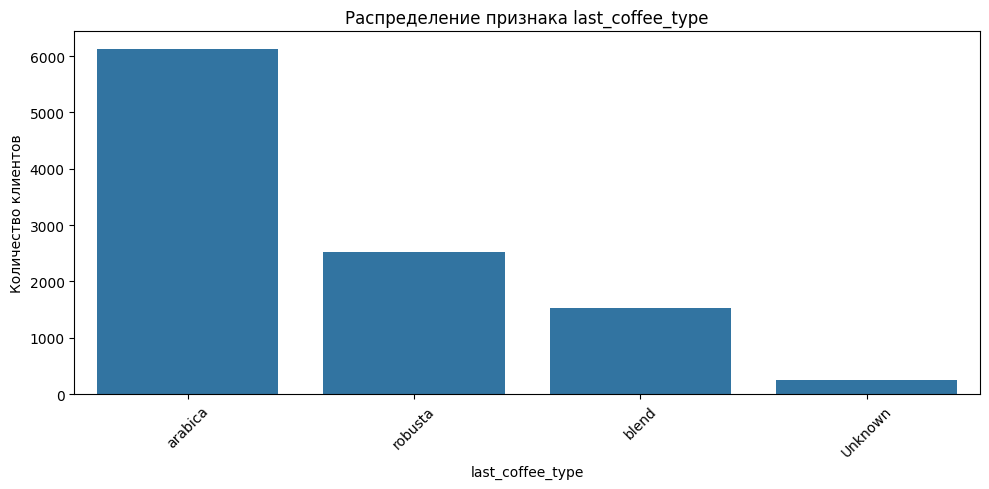

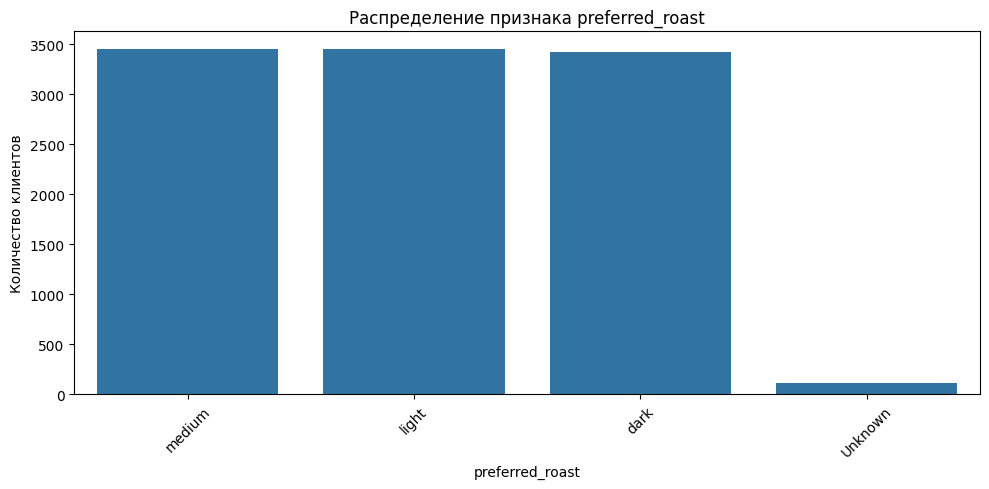

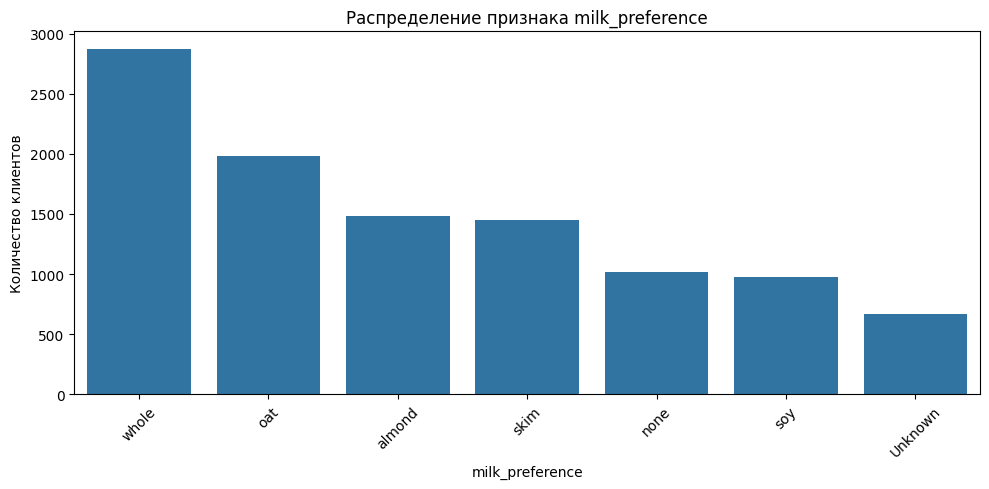

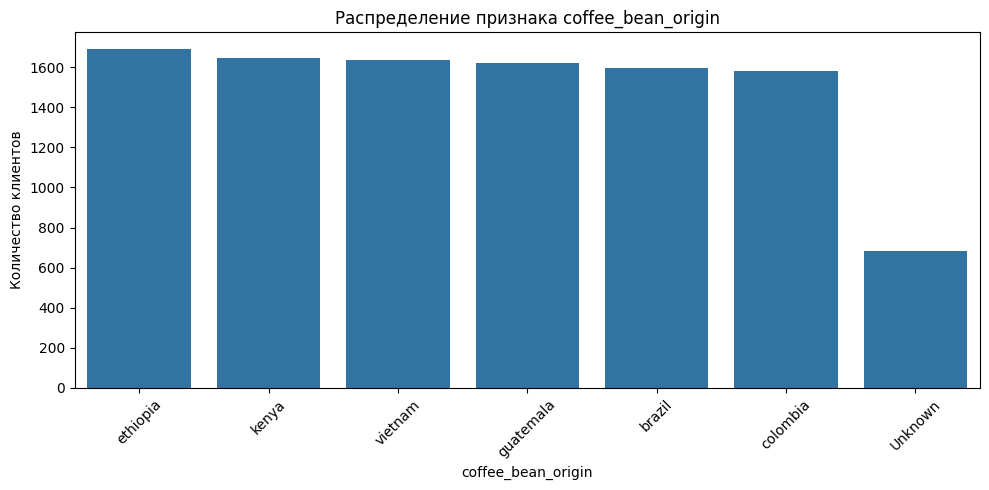

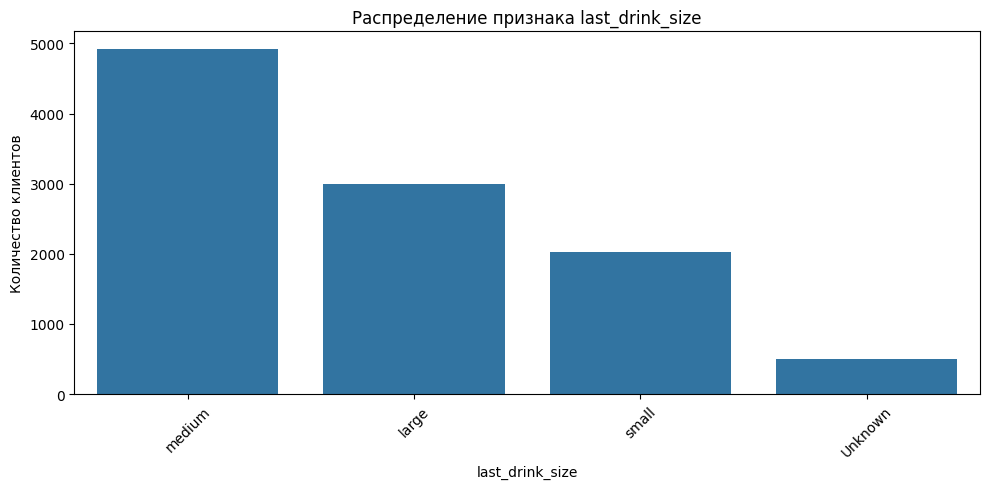

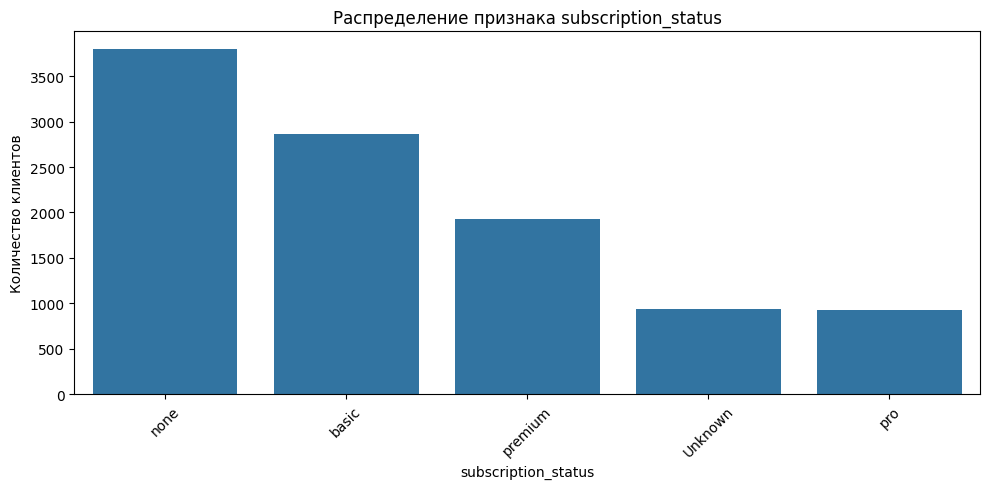

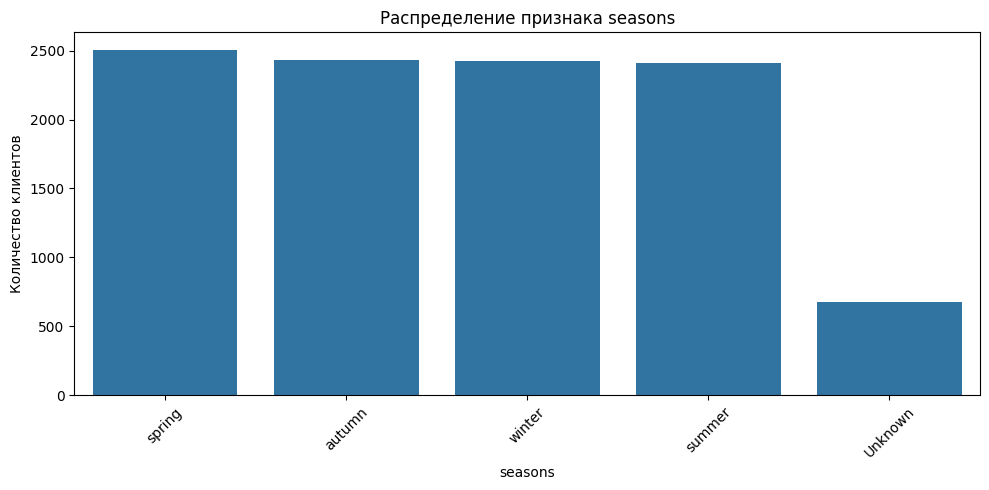

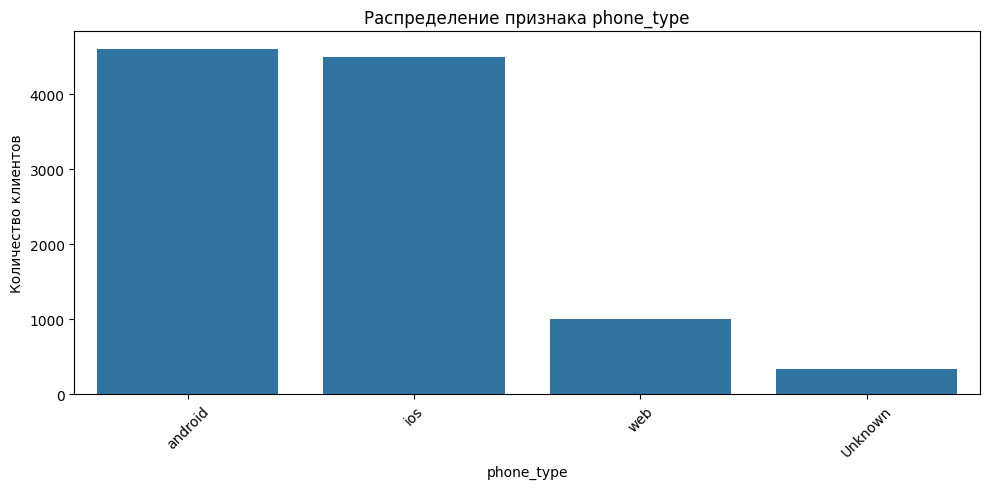

In [11]:
# Строим графики:

for col in CATEGORIAL_COLS:
    if col != 'geo_location':
        plt.figure(figsize=(10, 5))
        order = df[col].fillna('Unknown').value_counts().index
    
        sns.countplot(
            data=df.assign(**{col: df[col].fillna('Unknown')}),
            x=col,
            order=order
        )
    
        plt.title(f'Распределение признака {col}')
        plt.xlabel(col)
        plt.ylabel('Количество клиентов')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

,clients_count,churn_rate
last_coffee_type,,
Unknown,258,0.069767
robusta,2524,0.066165
blend,1534,0.060626
arabica,6134,0.057222


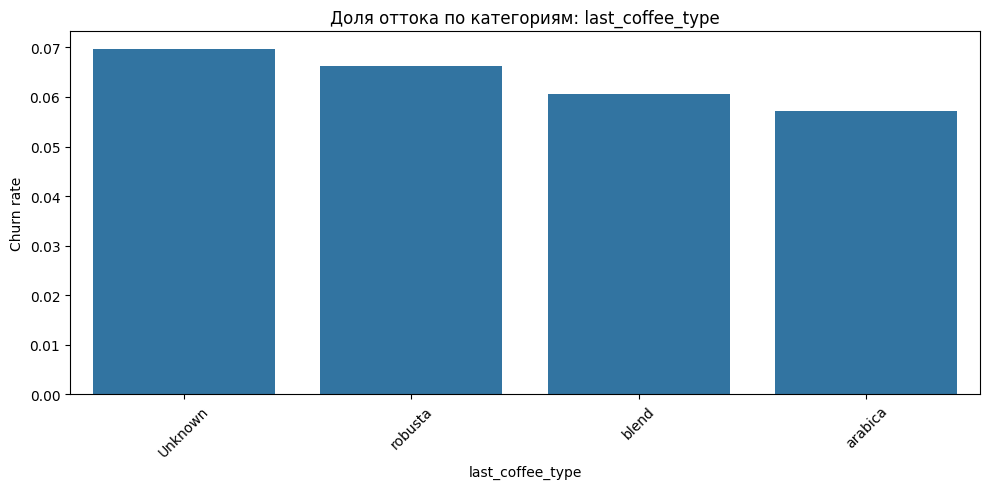

,clients_count,churn_rate
preferred_roast,,
dark,3423,0.060765
medium,3458,0.060729
light,3453,0.059948
Unknown,116,0.034483


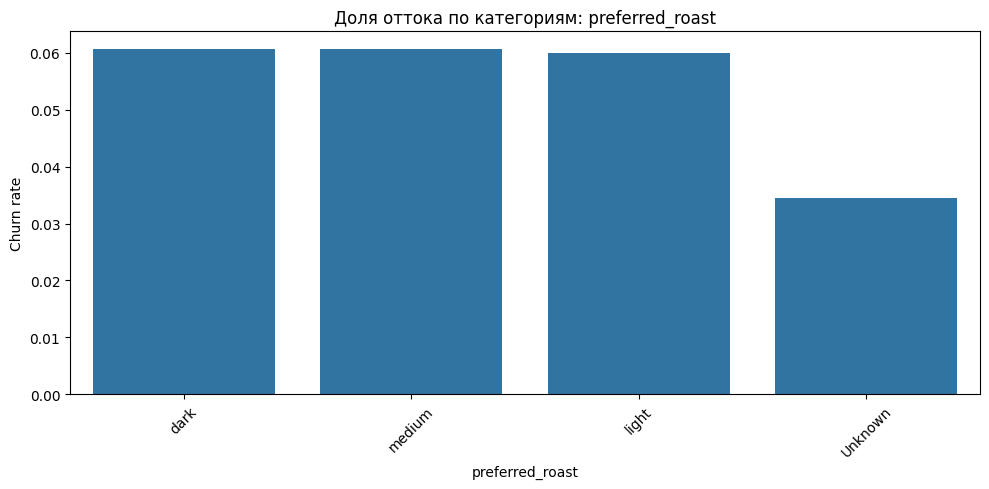

,clients_count,churn_rate
milk_preference,,
almond,1483,0.065408
whole,2876,0.061892
Unknown,668,0.059880
oat,1982,0.059536
skim,1451,0.058580
soy,975,0.056410
none,1015,0.055172


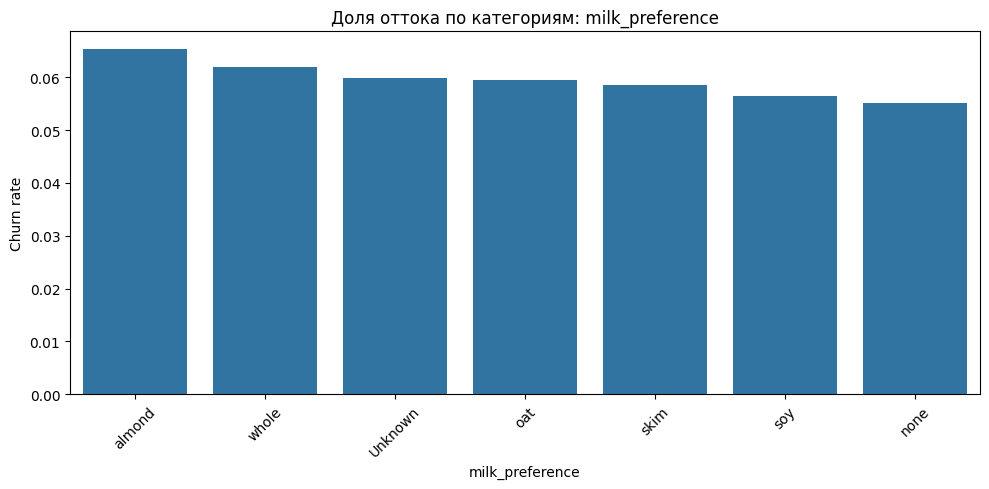

,clients_count,churn_rate
coffee_bean_origin,,
brazil,1596,0.065163
colombia,1580,0.063924
Unknown,682,0.063050
guatemala,1621,0.062307
ethiopia,1690,0.058580
vietnam,1635,0.056269
kenya,1646,0.054070


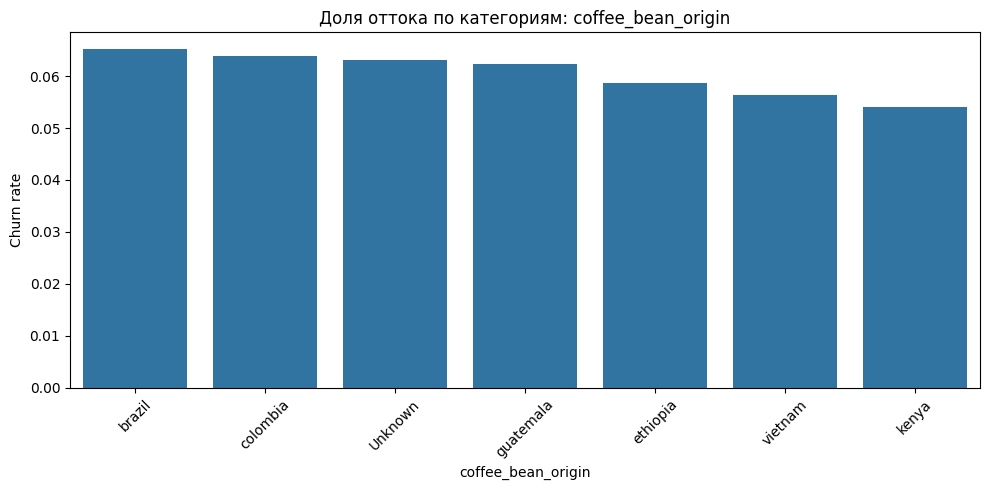

,clients_count,churn_rate
last_drink_size,,
Unknown,504,0.083333
large,2997,0.061395
small,2024,0.058300
medium,4925,0.057868


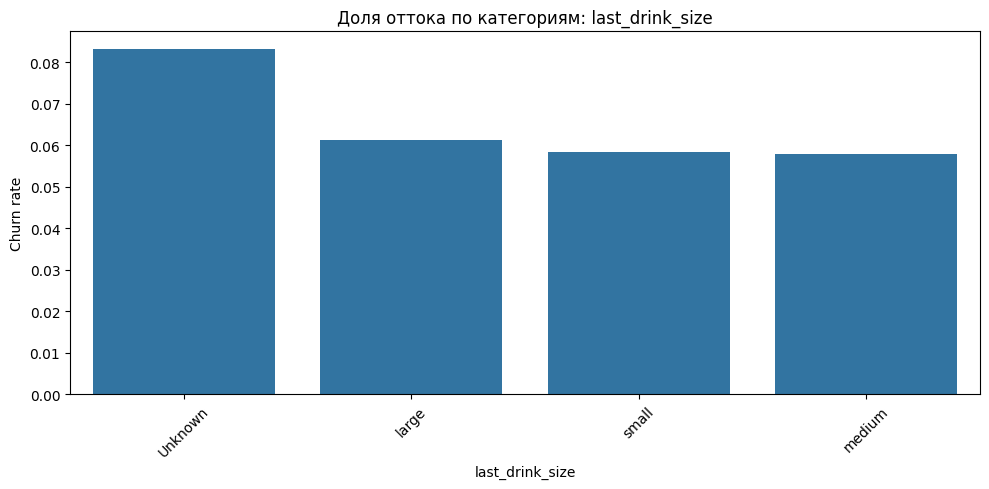

,clients_count,churn_rate
subscription_status,,
pro,924,0.108225
premium,1923,0.070203
basic,2862,0.053809
Unknown,938,0.052239
none,3803,0.050224


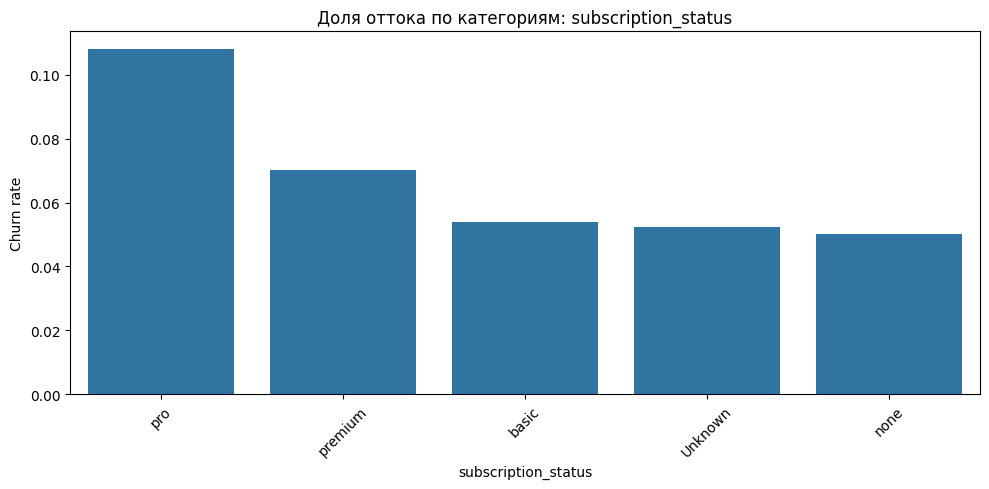

,clients_count,churn_rate
seasons,,
Unknown,679,0.079529
spring,2507,0.063422
autumn,2433,0.057953
winter,2423,0.056954
summer,2408,0.056894


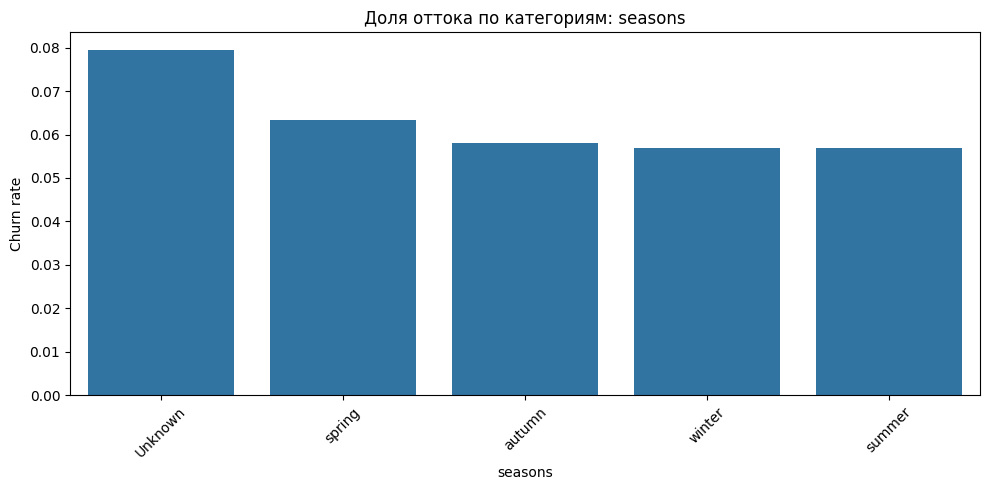

,clients_count,churn_rate
phone_type,,
android,4611,0.065279
web,1001,0.057942
ios,4502,0.057308
Unknown,336,0.035714


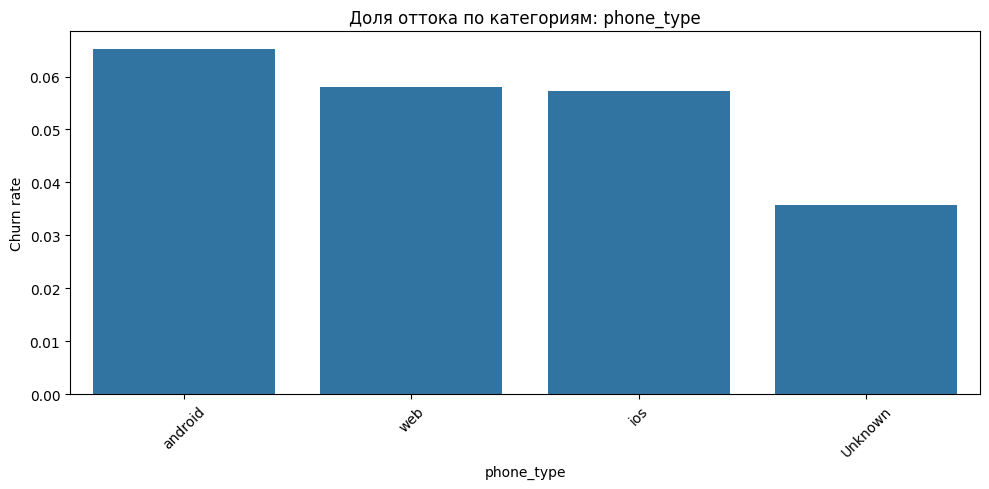

In [12]:
for col in CATEGORIAL_COLS:
    if col != 'geo_location':
        churn_by_cat = (
            df.assign(**{col: df[col].fillna('Unknown')})
            .groupby(col, dropna=False)[TARGET]
            .agg(['count', 'mean'])
            .rename(columns={'count': 'clients_count', 'mean': 'churn_rate'})
            .sort_values('churn_rate', ascending=False)
        )
        
        display(churn_by_cat)

        plt.figure(figsize=(10, 5))
        sns.barplot(
            x=churn_by_cat.index,
            y=churn_by_cat['churn_rate']
        )
        plt.title(f'Доля оттока по категориям: {col}')
        plt.xlabel(col)
        plt.ylabel('Churn rate')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

### Вывод по категориальным признакам

В датасете присутствуют категориальные признаки, описывающие вкусовые предпочтения клиента, особенности использования сервиса и внешний контекст. К ним относятся:
- `last_coffee_type` — сорт кофе, купленный пользователем в последний раз;
- `preferred_roast` — предпочитаемый тип обжарки;
- `milk_preference` — предпочитаемый тип молока;
- `coffee_bean_origin` — страна происхождения зерна;
- `last_drink_size` — размер последнего заказанного напитка;
- `subscription_status` — тип подписки пользователя;
- `seasons` — текущее время года;
- `phone_type` — тип устройства;
- `geo_location` — регион пользователя.

Анализ показал, что категориальные признаки имеют разную мощность множества значений:
- часть из них содержит небольшое число категорий и хорошо подходит для прямого кодирования;
- часть может иметь более высокую кардинальность, поэтому при предобработке нужно внимательно проверить, не приведёт ли кодирование к слишком сильному росту числа признаков.

Также в категориальных признаках есть пропуски. Удалять строки из-за этого нецелесообразно, поэтому на этапе предобработки пропущенные значения следует заменить отдельной категорией, например `"Unknown"`.

Анализ доли оттока по категориям позволяет проверить, есть ли у признаков потенциальная предсказательная сила. Если для некоторых категорий доля `churn` заметно отличается от остальных, это означает, что такие признаки могут быть полезны модели.

### Решение для дальнейшей работы

На этапе моделирования категориальные признаки:
- сохраняем;
- пропуски заполняем значением `"Unknown"`;
- кодируем с помощью `OneHotEncoder`.

In [13]:
# 6. Выбросы

numeric_summary = df[continuous_numeric_cols].describe().T

numeric_summary['missing_pct'] = (df[continuous_numeric_cols].isna().mean() * 100).round(2)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing_pct
days_since_last_order,9505.0,4.394214,4.858757,0.000000,1.000000,3.000000,6.000000,40.000000,9.04
order_frequency_month,9850.0,4.025666,2.826144,0.011046,1.937767,3.381094,5.439363,27.389318,5.74
order_frequency_week,10062.0,0.930686,0.657261,-0.169131,0.445185,0.784839,1.262350,6.302624,3.71
avg_order_value,9867.0,1063.741207,707.713396,-32.075932,552.898663,898.643524,1406.332153,5901.965278,5.58
median_order_value,9619.0,452.651500,258.657571,-10.353340,262.908598,406.456818,590.418070,2189.101644,7.95
total_spent_last_month,10156.0,1946.132979,2370.619590,-43.716463,629.680382,1300.409757,2481.650495,79298.849570,2.81
total_spent_last_week,9506.0,413.004760,445.634902,-2290.559468,136.565833,288.277327,549.699420,8615.988952,9.03
discount_usage_rate,10053.0,0.284446,0.158735,0.002162,0.159884,0.264583,0.387056,0.887301,3.80
app_opens_per_week,9554.0,11.330895,14.528887,0.000000,6.313628,9.228383,12.726649,224.587876,8.57
review_rating_last_10,9757.0,4.206709,0.782212,1.415526,3.675543,4.203555,4.717292,7.384425,6.63


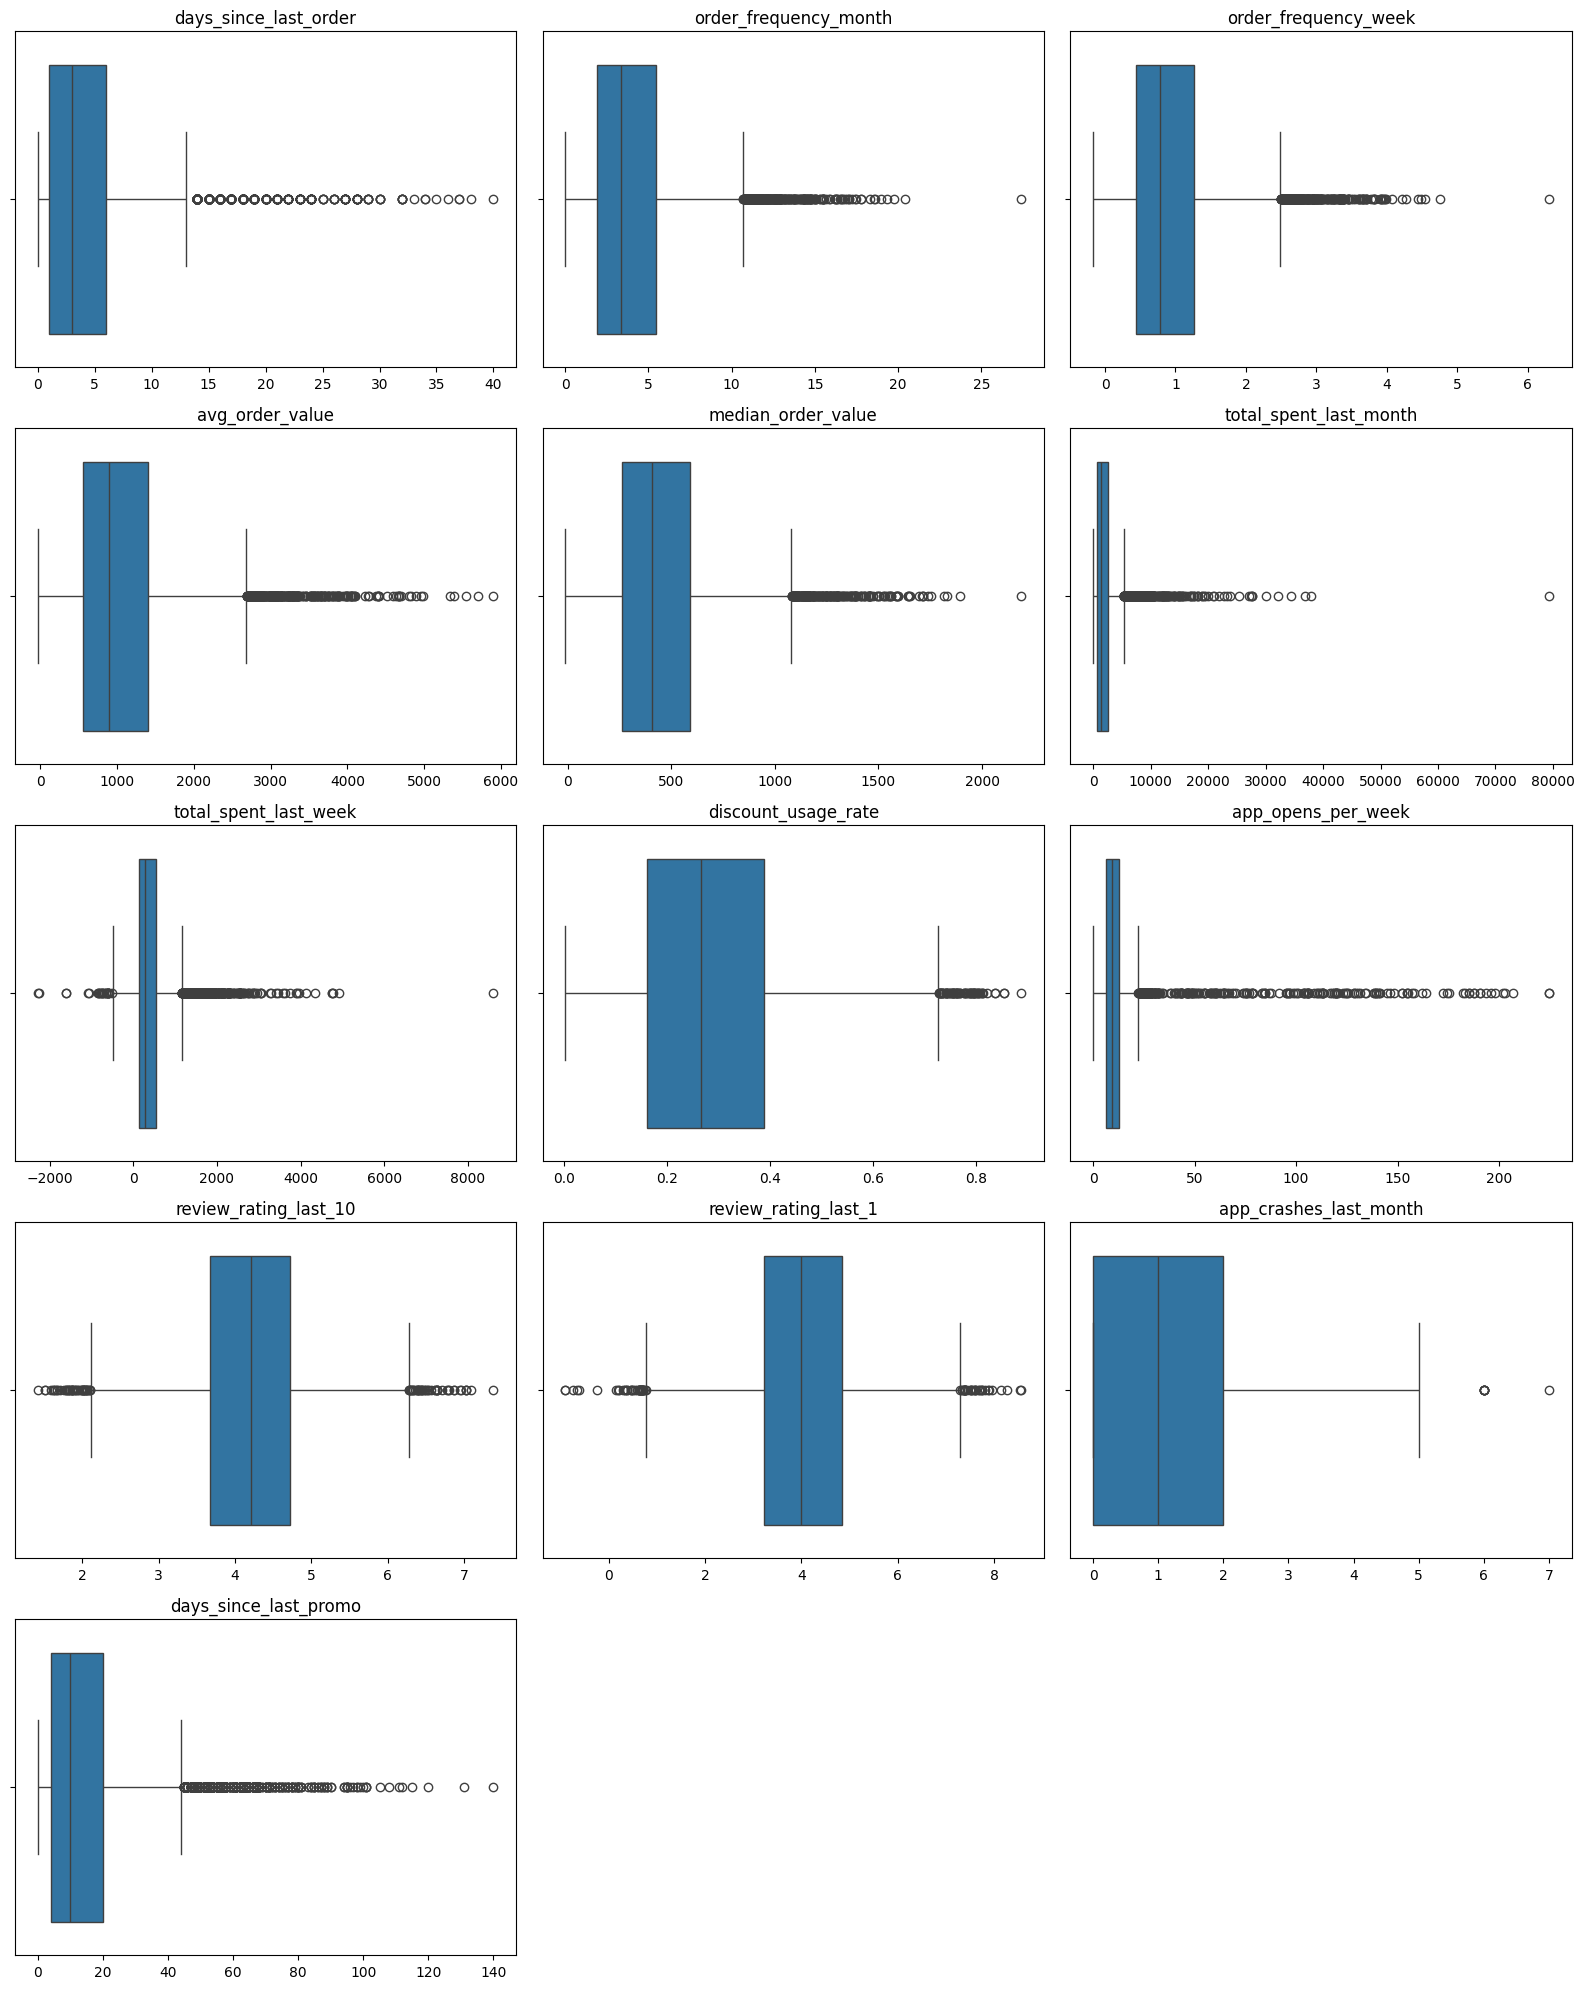

In [14]:
n_cols = 3
n_rows = int(np.ceil(len(continuous_numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Вывод по выбросам

Анализ числовых признаков с помощью boxplot показал, что в данных присутствуют выбросы. Наиболее заметны они в признаках, связанных с денежными тратами, частотой заказов, числом открытий приложения и давностью последней активности. Для многих таких признаков распределение имеет правый хвост: у небольшой части клиентов значения заметно выше, чем у основной массы наблюдений.

Это ожидаемо для бизнес-данных. Например:
- часть клиентов может делать особенно много заказов;
- часть клиентов может тратить значительно больше среднего;
- часть пользователей может очень активно пользоваться приложением.

Поэтому не каждый выброс следует считать ошибкой: некоторые экстремальные значения могут отражать реальное поведение клиентов и быть полезными для модели.

Однако в данных встречаются и значения, которые выглядят подозрительно уже не только статистически, но и логически. Например, отрицательные значения частоты заказов, среднего чека или суммы трат не имеют бизнес-смысла и скорее указывают на шум, ошибки генерации данных или проблемы агрегации.

### Выбранная стратегия обработки

#### 1. Логически некорректные значения
Такие значения, как отрицательные траты, отрицательная частота заказов или отрицательное число дней, следует считать ошибочными. Их лучше:
- заменить на `NaN`;
- затем обработать так же, как обычные пропуски, внутри пайплайна.

#### 2. Статистические, но правдоподобные экстремальные значения
Очень большие значения трат, активности или частоты заказов не обязательно являются ошибками. Полностью удалять такие строки не стоит, потому что можно потерять важных клиентов с нестандартным поведением.

Для таких значений:
- не удалять наблюдения;
- при необходимости ограничивать экстремумы методом clipping;
- использовать устойчивое масштабирование, например `RobustScaler`, чтобы уменьшить влияние длинных хвостов.

### Итоговое решение

На этапе EDA выбросы выявлены и проанализированы.  
Дальнейшая обработка будет такой:
- явно некорректные значения → заменить на `NaN`;
- правдоподобные экстремальные значения → не удалять, а снижать их влияние на этапе предобработки.

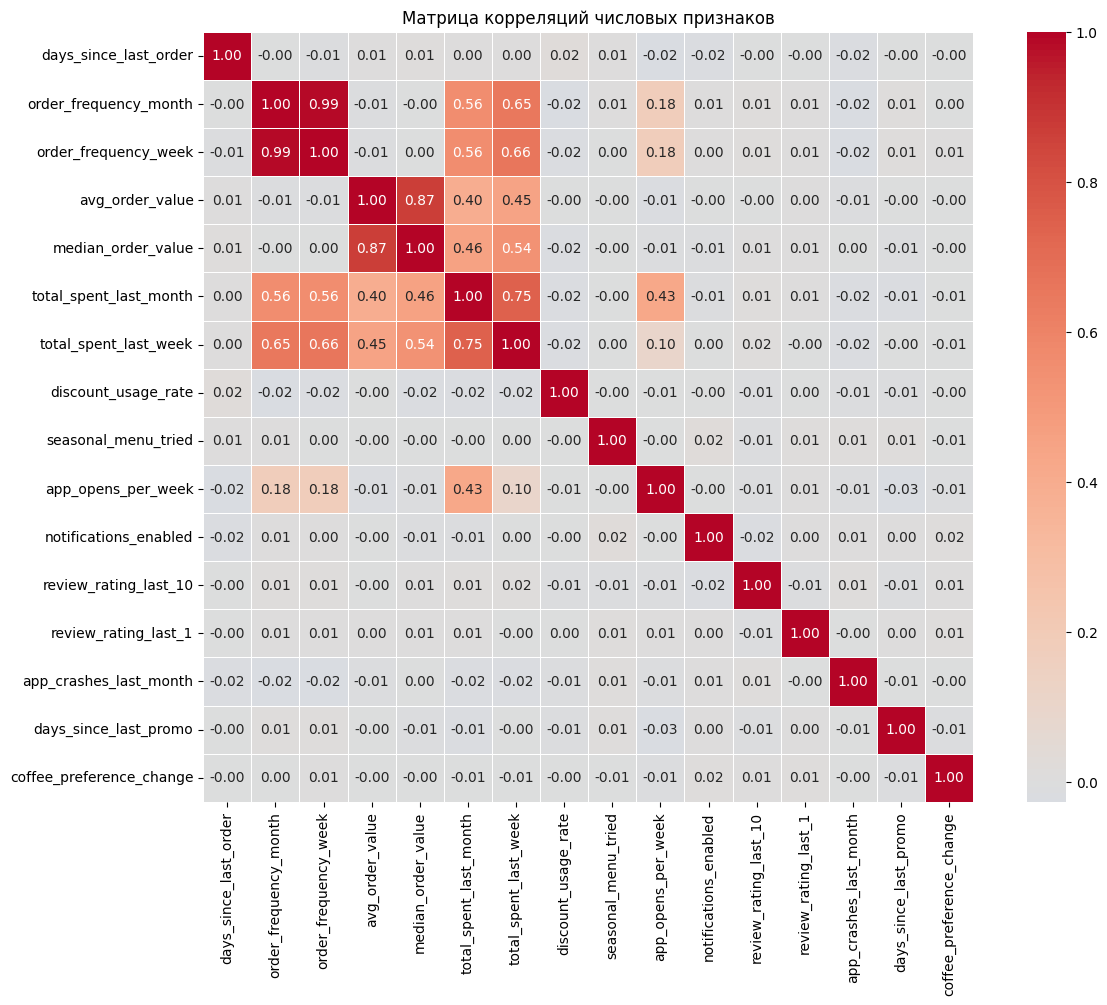

In [15]:
# 7. Корреляции

corr_matrix = df[NUMERIC_COLS].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Матрица корреляций числовых признаков')
plt.show()

### Вывод по корреляциям

В результате анализа были обнаружены следующие наиболее сильные связи:

- `order_frequency_month` и `order_frequency_week`: корреляция около **0.99**;
- `avg_order_value` и `median_order_value`: корреляция около **0.87**;
- `total_spent_last_month` и `total_spent_last_week`: корреляция около **0.75**.

### Интерпретация результатов

#### 1. `order_frequency_month` и `order_frequency_week`
Это почти полностью дублирующие друг друга признаки. Оба описывают частоту заказов, только в разном временном масштабе. Корреляция около 0.99 говорит о том, что они несут практически одну и ту же информацию.

Поэтому один из этих признаков можно удалить без существенной потери информации.  
В дальнейшем разумно оставить `order_frequency_month`, а `order_frequency_week` удалить:
- месячная частота более устойчива;
- она удобнее интерпретируется в бизнес-контексте;
- это уменьшит избыточность признакового пространства.

#### 2. `avg_order_value` и `median_order_value`
Связь между этими признаками высокая, но не почти полная. Оба признака описывают чек клиента, однако делают это по-разному:
- средний чек отражает общий уровень трат;
- медианный чек менее чувствителен к выбросам.

Поэтому на текущем этапе удалять один из них не обязательно. Их можно оставить и вернуться к этому вопросу позже — после обучения модели и анализа коэффициентов.

#### 3. `total_spent_last_month` и `total_spent_last_week`
Корреляция между ними заметная, но не критическая. Эти признаки отражают траты клиента на разных временных горизонтах:
- за неделю;
- за месяц.

Так как они описывают разные аспекты поведения клиента, сохранять оба признака на текущем этапе допустимо.

### Итоговое решение

На основании корреляционного анализа явным кандидатом на удаление является:
- `order_frequency_week`

Остальные признаки с заметной корреляцией пока можно сохранить, потому что они всё же отражают разные стороны клиентского поведения и могут быть полезны модели.

### Итоговый вывод по этапу 2

На этапе исследовательского анализа данных был изучен состав датасета, типы признаков, структура целевой переменной, наличие пропусков, категориальные и числовые признаки, выбросы и корреляции между признаками.

В результате анализа установлено, что датасет подходит для решения задачи бинарной классификации: каждая строка соответствует одному клиенту, а целевая переменная `churn` отражает факт его ухода из сервиса. Признаки описывают покупательскую активность клиента, его вкусовые предпочтения, взаимодействие с приложением, пользовательский опыт и контекстные характеристики. Описание признаков подтверждает, что они содержательно связаны с задачей прогнозирования оттока. 

Основные выводы по результатам EDA:

1. **Целевая переменная несбалансирована.**  
   Класс ушедших клиентов представлен заметно реже, чем класс лояльных клиентов. Это означает, что при обучении модели нельзя ориентироваться только на `accuracy`. Для оценки качества более важны метрики, чувствительные к миноритарному классу: `precision`, `recall`, `F1` и `PR AUC`. Также при дальнейшем моделировании необходимо использовать стратифицированное разбиение и стратифицированную кросс-валидацию.

2. **В данных присутствуют пропуски, но удалять строки или признаки нецелесообразно.**  
   Пропуски встречаются во многих столбцах, однако сами признаки при этом остаются потенциально полезными для модели. Поэтому оптимальная стратегия — не отбрасывать данные, а обрабатывать пропущенные значения внутри пайплайна:
   - непрерывные числовые признаки — заполнять медианой;
   - бинарные числовые признаки — самым частым значением;
   - категориальные признаки — отдельной категорией `"Unknown"`.

3. **Признаки корректно разделяются на числовые и категориальные.**  
   Для этого учитывались как технические типы столбцов в `pandas`, так и смысл признаков. Среди числовых признаков отдельно были выделены бинарные признаки, поскольку для них нужна особая логика обработки.

4. **Технический признак `user_id` не нужен для моделирования.**  
   Он представляет собой идентификатор клиента, не несёт полезной информации о его поведении и не должен участвовать в обучении модели. Этот признак следует удалить.

5. **Категориальные признаки содержат полезную информацию и должны быть сохранены.**  
   Они описывают предпочтения клиента, подписку, сезон, устройство и регион. Для логистической регрессии такие признаки потребуется закодировать, например с помощью `OneHotEncoder`, предварительно обработав пропуски.

6. **В числовых признаках обнаружены выбросы.**  
   Часть экстремальных значений может отражать реальное поведение клиентов и потому не требует удаления. Однако значения, которые выглядят логически некорректными, например отрицательные траты или отрицательная частота заказов, следует считать ошибочными. Такие значения разумно заменить на `NaN`, а затем обработать как пропуски в пайплайне. Для уменьшения влияния правых хвостов и экстремумов на линейную модель желательно использовать устойчивую предобработку признаков.

7. **Между некоторыми признаками есть высокая корреляция.**  
   Наиболее сильная связь наблюдается между `order_frequency_month` и `order_frequency_week`, поэтому один из этих признаков можно удалить без существенной потери информации. Наиболее логично оставить `order_frequency_month`, а `order_frequency_week` исключить.  
   Для пар `avg_order_value` — `median_order_value` и `total_spent_last_month` — `total_spent_last_week` связь заметна, но на данном этапе удалять признаки необязательно, поскольку они всё ещё отражают разные стороны поведения клиента.

### Общий итог

По итогам EDA датасет признан пригодным для построения модели прогнозирования оттока.  
Для дальнейшей работы принято следующее решение:
- удалить `user_id`;
- в будущем удалить `order_frequency_week` как избыточный признак;
- сохранить остальные содержательные признаки;
- пропуски обрабатывать внутри пайплайна;
- категориальные признаки кодировать;
- логически некорректные выбросы заменять на `NaN`;
- при обучении учитывать дисбаланс классов и оценивать модель с помощью метрик, ориентированных на качество распознавания оттока.

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [16]:
# 1. Разделение данных

def replace_negative_with_nan(X):
    X = X.copy()
    X[X < 0] = np.nan
    return X


def drop_redundant_features(X):
    X = X.copy()
    return X.drop(columns=['order_frequency_week'], errors='ignore')


df_y = df['churn']
df_x = df.drop(columns=['churn'])

x_train_val, x_test, y_train_val, y_test = train_test_split(
    df_x,
    df_y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_y
)

In [17]:
# 2. Построение пайплайна

# Удаление order_frequency_week теперь происходит внутри модельной части
X_train_prepared = drop_redundant_features(x_train_val)

numeric_features = X_train_prepared.select_dtypes(include='number').columns.tolist()
categorical_features = X_train_prepared.select_dtypes(include='object').columns.tolist()

binary_numeric_features = [
    col for col in numeric_features
    if X_train_prepared[col].dropna().nunique() == 2
]

continuous_numeric_features = [
    col for col in numeric_features
    if col not in binary_numeric_features
]

C:\Users\yanoc\AppData\Local\Temp\ipykernel_3292\30180179.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train_prepared.select_dtypes(include='object').columns.tolist()


In [18]:
negative_to_nan = FunctionTransformer(replace_negative_with_nan)

scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

cat_pipeline = Pipeline(steps=[
    ('imputer', cat_imputer),
    ('encoder', encoder)
])

binary_num_pipeline = Pipeline(steps=[
    ('negative_to_nan', negative_to_nan),
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

continuous_num_pipeline = Pipeline(steps=[
    ('negative_to_nan', negative_to_nan),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', scaler)
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_pipeline, categorical_features),
    ('bin_num', binary_num_pipeline, binary_numeric_features),
    ('cont_num', continuous_num_pipeline, continuous_numeric_features)
])

### Вывод по этапу 3

На этом этапе были подготовлены данные для последующего обучения модели. Сначала в числовых признаках были обработаны некорректные отрицательные значения: они заменены на пропуски, так как такие значения не имеют практического смысла и могут исказить результаты анализа. Затем целевой признак `churn` был отделён от остальных переменных, а данные разделены на обучающую и тестовую выборки со стратификацией по целевой переменной, что позволяет сохранить исходный баланс классов.

После этого был построен препроцессор для разных типов признаков. Категориальные признаки обрабатываются через заполнение пропусков значением `Unknown` и последующее one-hot кодирование. Бинарные числовые признаки заполняются наиболее частым значением, а непрерывные числовые — медианой с последующей стандартизацией. Такой подход позволяет подготовить данные к обучению модели корректно и единообразно. При этом сами преобразования будут применяться уже на следующем этапе внутри общего пайплайна вместе с моделью, что помогает избежать утечки данных.

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [19]:
# 1, 2. Обучение модели и расчет метрик

def evaluate_pipeline_cv(pipeline, X, y, random_state=RANDOM_STATE, n_folds=N_FOLDS):
    kfold = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=random_state
    )

    cv_results = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y), start=1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        pipeline.fit(X_train_fold, y_train_fold)

        y_val_pred = pipeline.predict(X_val_fold)
        y_val_proba = pipeline.predict_proba(X_val_fold)[:, 1]

        cv_results.append({
            'fold': fold,
            'precision': precision_score(y_val_fold, y_val_pred, zero_division=0),
            'recall': recall_score(y_val_fold, y_val_pred, zero_division=0),
            'f1': f1_score(y_val_fold, y_val_pred, zero_division=0),
            'pr_auc': average_precision_score(y_val_fold, y_val_proba)
        })

    return pd.DataFrame(cv_results)

# Сравнение с базовым алгоритмом
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='prior'))
])

base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

dummy_results_df = evaluate_pipeline_cv(dummy_pipeline, x_train_val, y_train_val)
cv_results_df = evaluate_pipeline_cv(base_pipeline, x_train_val, y_train_val)

comparison_stage4 = pd.DataFrame([
    dummy_results_df[['precision', 'recall', 'f1', 'pr_auc']].mean(),
    cv_results_df[['precision', 'recall', 'f1', 'pr_auc']].mean()
], index=[
    'dummy_baseline',
    'logistic_regression'
]).round(4)

comparison_stage4

,precision,recall,f1,pr_auc
dummy_baseline,0.0000,0.0000,0.0000,0.0602
logistic_regression,0.7456,0.4613,0.5644,0.6525


In [20]:
dummy_summary = pd.DataFrame({
    'mean': dummy_results_df[['precision', 'recall', 'f1', 'pr_auc']].mean(),
    'std': dummy_results_df[['precision', 'recall', 'f1', 'pr_auc']].std()
}).round(4)

cv_summary = pd.DataFrame({
    'mean': cv_results_df[['precision', 'recall', 'f1', 'pr_auc']].mean(),
    'std': cv_results_df[['precision', 'recall', 'f1', 'pr_auc']].std()
}).round(4)

print('Dummy baseline')
display(dummy_summary)

print('Логистическая регрессия')
cv_summary

Dummy baseline


,mean,std
precision,0.0000,0.0000
recall,0.0000,0.0000
f1,0.0000,0.0000
pr_auc,0.0602,0.0003


Логистическая регрессия


,mean,std
precision,0.7456,0.0724
recall,0.4613,0.0901
f1,0.5644,0.0724
pr_auc,0.6525,0.0561


### Вывод по этапу 4

На этом этапе была обучена базовая модель — логистическая регрессия. Для оценки её качества использовалась стратифицированная 5-fold кросс-валидация, поскольку целевая переменная сильно несбалансирована: доля ушедших клиентов составляет около 6%, а доля лояльных — около 94%. Стратификация позволила сохранить это соотношение классов в каждом фолде и получить более надёжную оценку качества модели.

В соответствии с постановкой задачи были рассчитаны метрики **Precision**, **Recall**, **F1-мера** и **PR AUC**. Основной метрикой выбрана **PR AUC**, так как она лучше отражает качество модели в условиях дисбаланса классов и фокусируется именно на качестве распознавания уходящих клиентов.

Средние результаты кросс-валидации:
- **Precision**: 0.7456
- **Recall**: 0.4613
- **F1-score**: 0.5644
- **PR AUC**: 0.6525

Полученные результаты нельзя считать плохими для базовой модели. Модель показывает достаточно высокий **precision**, то есть среди клиентов, которых она относит к потенциально уходящим, значительная часть действительно относится к положительному классу. Это важно для бизнеса, поскольку уменьшает число ложных срабатываний и позволяет более экономно расходовать бюджет на удержание.

При этом **recall** остаётся умеренным: модель находит не всех клиентов, склонных к оттоку, а примерно 46% от их общего числа. Это означает, что базовая модель пока пропускает часть действительно уходящих клиентов. Таким образом, текущая версия модели скорее делает более осторожные предсказания: она лучше подтверждает отток, чем максимально широко его охватывает.

Наиболее важный результат — значение **PR AUC = 0.6525**. Для данной задачи это хороший показатель, поскольку он существенно выше уровня случайного угадывания. При доле положительного класса около 6% случайная модель имела бы PR AUC примерно на уровне 0.06. Следовательно, даже базовая логистическая регрессия уже улавливает полезные закономерности в данных и может служить качественной отправной точкой для дальнейшего улучшения.

Итог: базовая модель показала осмысленный и рабочий результат. Её качество нельзя назвать окончательным, однако она уже заметно лучше случайного предсказания и подходит в качестве baseline для следующих этапов проекта — создания новых признаков, подбора гиперпараметров и возможной настройки порога классификации.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [21]:
# Еще раз посмотрим на таблицу с признаками

df_x.describe().round(2)

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change
count,9505.00,9850.00,10062.00,9867.00,9619.00,10156.00,9506.00,10053.00,9461.00,9554.00,9913.00,9757.00,9593.00,9729.00,9719.00,9840.00
mean,4.39,4.03,0.93,1063.74,452.65,1946.13,413.00,0.28,0.70,11.33,0.75,4.21,4.02,1.01,14.55,0.19
std,4.86,2.83,0.66,707.71,258.66,2370.62,445.63,0.16,0.46,14.53,0.43,0.78,1.21,1.01,15.31,0.39
min,0.00,0.01,-0.17,-32.08,-10.35,-43.72,-2290.56,0.00,0.00,0.00,0.00,1.42,-0.90,0.00,0.00,0.00
25%,1.00,1.94,0.45,552.90,262.91,629.68,136.57,0.16,0.00,6.31,1.00,3.68,3.21,0.00,4.00,0.00
50%,3.00,3.38,0.78,898.64,406.46,1300.41,288.28,0.26,1.00,9.23,1.00,4.20,3.99,1.00,10.00,0.00
75%,6.00,5.44,1.26,1406.33,590.42,2481.65,549.70,0.39,1.00,12.73,1.00,4.72,4.85,2.00,20.00,0.00
max,40.00,27.39,6.30,5901.97,2189.10,79298.85,8615.99,0.89,1.00,224.59,1.00,7.38,8.56,7.00,140.00,1.00


### Выбор новых признаков

Методом "научного тыка" (анализа данных и перебора было выявлено):

- app_opens_per_week_log1p - Сглаживает сильную правую асимметрию по открытиям приложения.
- crashes_any - Флаг: были ли вообще сбои приложения.
- app_crashes_last_month_sq - Квадрат числа сбоев (влияние сбоев явно нелинейное: несколько сбоев подряд сильно повышают риск оттока).
- crashes_per_open - Отношение сбоев к активности (если клиент часто открывает приложение и постоянно ловит сбои, это сильный сигнал).

#### Дополнение

Будем делать 2 функции - в одной удалим исходный признак app_opens_per_week_log1p, оставив только преобразованный. Во второй - оставим и тот, и тот. 
Потом сравним.

In [22]:
# 1. Добавление новых признаков

# Функция, где оба признака остаются
def add_features(X):
    X = X.copy()

    # 1. Сглаживаем сильно скошенный признак активности
    X['app_opens_per_week_log1p'] = np.log1p(X['app_opens_per_week'].clip(lower=0))

    # 2. Нелинейность по числу сбоев
    X['crashes_any'] = np.where(
    X['app_crashes_last_month'].isna(),
    np.nan,
    (X['app_crashes_last_month'] > 0).astype(float)
    )
    X['app_crashes_last_month_sq'] = X['app_crashes_last_month'] ** 2

    # 3. Относительная "проблемность" приложения
    X['crashes_per_open'] = X['app_crashes_last_month'] / (X['app_opens_per_week'] + 1)

    return X

# Функция, где исходный признак удаляется
def add_features_drop_original(X):
    X = X.copy()

    X['app_opens_per_week_log1p'] = np.log1p(X['app_opens_per_week'].clip(lower=0))
    X = X.drop(columns=['app_opens_per_week'])

    X['crashes_any'] = np.where(
    X['app_crashes_last_month'].isna(),
    np.nan,
    (X['app_crashes_last_month'] > 0).astype(float)
    )
    X['app_crashes_last_month_sq'] = X['app_crashes_last_month'] ** 2

    # Здесь уже используем логарифмированную версию, раз исходную удалили
    X['crashes_per_open'] = X['app_crashes_last_month'] / (X['app_opens_per_week_log1p'] + 1)

    return X


x_train_val_fe_keep = add_features(x_train_val)
x_test_fe_keep = add_features(x_test)

x_train_val_fe_drop = add_features_drop_original(x_train_val)
x_test_fe_drop = add_features_drop_original(x_test)

In [23]:
# 2. Обновляем пайплайн, уже без утечек (для удобства, сделаем функции)

def build_preprocessor(X_train):
    X_train = drop_redundant_features(X_train)

    numeric_features = X_train.select_dtypes(include='number').columns.tolist()
    categorical_features = X_train.select_dtypes(include='object').columns.tolist()

    binary_numeric_features = [
        col for col in numeric_features
        if X_train[col].dropna().nunique() == 2
    ]

    continuous_numeric_features = [
        col for col in numeric_features
        if col not in binary_numeric_features
    ]

    cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

    binary_num_pipeline = Pipeline(steps=[
        ('negative_to_nan', FunctionTransformer(replace_negative_with_nan)),
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    continuous_num_pipeline = Pipeline(steps=[
        ('negative_to_nan', FunctionTransformer(replace_negative_with_nan)),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('cat', cat_pipeline, categorical_features),
        ('bin_num', binary_num_pipeline, binary_numeric_features),
        ('cont_num', continuous_num_pipeline, continuous_numeric_features)
    ])

    return preprocessor


def evaluate_model_cv(X, y, random_state=RANDOM_STATE, n_folds=N_FOLDS):
    preprocessor = build_preprocessor(X)

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            random_state=random_state,
            max_iter=1000
        ))
    ])

    kfold = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=random_state
    )

    cv_results = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y), start=1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        pipeline.fit(X_train_fold, y_train_fold)

        y_val_pred = pipeline.predict(X_val_fold)
        y_val_proba = pipeline.predict_proba(X_val_fold)[:, 1]

        cv_results.append({
            'fold': fold,
            'precision': precision_score(y_val_fold, y_val_pred, zero_division=0),
            'recall': recall_score(y_val_fold, y_val_pred, zero_division=0),
            'f1': f1_score(y_val_fold, y_val_pred, zero_division=0),
            'pr_auc': average_precision_score(y_val_fold, y_val_proba)
        })

    cv_results_df_new = pd.DataFrame(cv_results)

    cv_summary_new = pd.DataFrame({
        'mean': cv_results_df_new[['precision', 'recall', 'f1', 'pr_auc']].mean(),
        'std': cv_results_df_new[['precision', 'recall', 'f1', 'pr_auc']].std()
    }).round(4)

    return cv_results_df_new, cv_summary_new, pipeline

In [24]:
# Проверка, какой вариант лучше

# Вариант 1: исходный app_opens_per_week оставляем
cv_results_keep, cv_summary_keep, pipeline_keep = evaluate_model_cv(
    x_train_val_fe_keep,
    y_train_val
)

# Вариант 2: исходный app_opens_per_week удаляем
cv_results_drop, cv_summary_drop, pipeline_drop = evaluate_model_cv(
    x_train_val_fe_drop,
    y_train_val
)

print('Вариант KEEP')
display(cv_results_keep.round(4))
display(cv_summary_keep)

print('Вариант DROP')
display(cv_results_drop.round(4))
display(cv_summary_drop)

C:\Users\yanoc\AppData\Local\Temp\ipykernel_3292\1334724270.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include='object').columns.tolist()
C:\Users\yanoc\AppData\Local\Temp\ipykernel_3292\1334724270.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pyda

Вариант KEEP


,fold,precision,recall,f1,pr_auc
0,1,0.6625,0.5300,0.5889,0.6704
1,2,0.7534,0.5500,0.6358,0.6645
2,3,0.8000,0.4752,0.5963,0.7088
3,4,0.8000,0.6337,0.7072,0.7996
4,5,0.8596,0.4851,0.6203,0.7084


,mean,std
precision,0.7751,0.0734
recall,0.5348,0.0633
f1,0.6297,0.0472
pr_auc,0.7104,0.0540


Вариант DROP


,fold,precision,recall,f1,pr_auc
0,1,0.6456,0.5100,0.5698,0.6572
1,2,0.7467,0.5600,0.6400,0.6617
2,3,0.7759,0.4455,0.5660,0.6920
3,4,0.7922,0.6040,0.6854,0.7917
4,5,0.8421,0.4752,0.6076,0.7017


,mean,std
precision,0.7605,0.0730
recall,0.5190,0.0638
f1,0.6138,0.0502
pr_auc,0.7008,0.0543


In [25]:
# 3. сравниваем с этапом 4 и между собой

# Средние метрики baseline из этапа 4
baseline_mean = cv_results_df[['precision', 'recall', 'f1', 'pr_auc']].mean()

# Средние метрики новых вариантов
keep_mean = cv_results_keep[['precision', 'recall', 'f1', 'pr_auc']].mean()
drop_mean = cv_results_drop[['precision', 'recall', 'f1', 'pr_auc']].mean()

comparison = pd.DataFrame([
    baseline_mean,
    keep_mean,
    drop_mean
], index=[
    'baseline',
    'feature_engineering_keep_original',
    'feature_engineering_drop_original'
]).round(4)

comparison

,precision,recall,f1,pr_auc
baseline,0.7456,0.4613,0.5644,0.6525
feature_engineering_keep_original,0.7751,0.5348,0.6297,0.7104
feature_engineering_drop_original,0.7605,0.5190,0.6138,0.7008


In [26]:
# 3. Интерпретация коэффициентов и проверка на наличие слабых признаков

stage5_preprocessor = build_preprocessor(x_train_val_fe_keep)

stage5_model = Pipeline(steps=[
    ('preprocessor', stage5_preprocessor),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

stage5_model.fit(x_train_val_fe_keep, y_train_val)

def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == 'remainder' or transformer == 'drop':
            continue

        if name == 'cat':
            encoder = transformer.named_steps['encoder']
            feature_names.extend(encoder.get_feature_names_out(columns))
        else:
            feature_names.extend(list(columns))

    return feature_names

stage5_preprocessor_fitted = stage5_model.named_steps['preprocessor']
stage5_lr = stage5_model.named_steps['model']

stage5_feature_names = get_feature_names_from_preprocessor(stage5_preprocessor_fitted)

stage5_coef_table = pd.DataFrame({
    'feature': stage5_feature_names,
    'coefficient': stage5_lr.coef_[0]
})

stage5_coef_table['abs_coefficient'] = stage5_coef_table['coefficient'].abs()
stage5_coef_table = stage5_coef_table.sort_values('abs_coefficient')

stage5_coef_table.head(20)

C:\Users\yanoc\AppData\Local\Temp\ipykernel_3292\1334724270.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include='object').columns.tolist()


,feature,coefficient,abs_coefficient
40,geo_location_Unknown,-0.002317,0.002317
72,geo_location_geo_37,-0.003044,0.003044
38,phone_type_ios,0.003474,0.003474
107,geo_location_geo_69,-0.008828,0.008828
145,days_since_last_order,0.022605,0.022605
151,discount_usage_rate,-0.023079,0.023079
16,coffee_bean_origin_brazil,-0.024888,0.024888
58,geo_location_geo_24,-0.028761,0.028761
43,geo_location_geo_100,-0.029447,0.029447
26,subscription_status_Unknown,-0.029947,0.029947


### Интерпретация коэффициентов и отбор признаков

После обучения модели с новыми признаками были проанализированы коэффициенты логистической регрессии.

Анализ показал, что среди добавленных engineered-признаков не оказалось признаков с коэффициентами, близкими к нулю.

Некоторые отдельные one-hot-кодированные категории действительно имели очень маленькие коэффициенты.
Однако такие столбцы представляют собой не самостоятельные исходные признаки, а отдельные категории более крупных признаков.
Поэтому удалять их по отдельности нецелесообразно без дополнительной перегруппировки категорий.

### Вывод по этапу 5

На этапе feature engineering были добавлены новые признаки, отражающие:
- нелинейную зависимость между активностью пользователя в приложении и оттоком;
- наличие технических проблем в приложении;
- интенсивность этих проблем;
- относительную "проблемность" приложения для пользователя.

Были протестированы два варианта:
1. `feature_engineering_keep_original` — исходный признак `app_opens_per_week` сохранялся, а его логарифмированная версия добавлялась как новый признак;
2. `feature_engineering_drop_original` — исходный признак `app_opens_per_week` удалялся после логарифмирования.

Результаты кросс-валидации показали, что наилучшее качество даёт вариант `feature_engineering_keep_original`:

- `precision = 0.7751`
- `recall = 0.5348`
- `f1 = 0.6297`
- `pr_auc = 0.7104`

По сравнению с baseline-моделью:
- `precision` вырос с `0.7456` до `0.7751` (+3%);
- `recall` вырос с `0.4613` до `0.5348` (+7%);
- `f1` вырос с `0.5644` до `0.6297` (+6%);
- `pr_auc` вырос с `0.6525` до `0.7104` (+6%).

Таким образом, добавленные признаки оказались полезными.
Наиболее удачным оказался вариант, в котором исходный признак `app_opens_per_week` был сохранён, а его логарифмированная версия использовалась как дополнительный источник информации.

Следовательно, для дальнейших этапов проекта будет использоваться набор признаков `feature_engineering_keep_original`.

C:\Users\yanoc\AppData\Local\Temp\ipykernel_3292\1334724270.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include='object').columns.tolist()


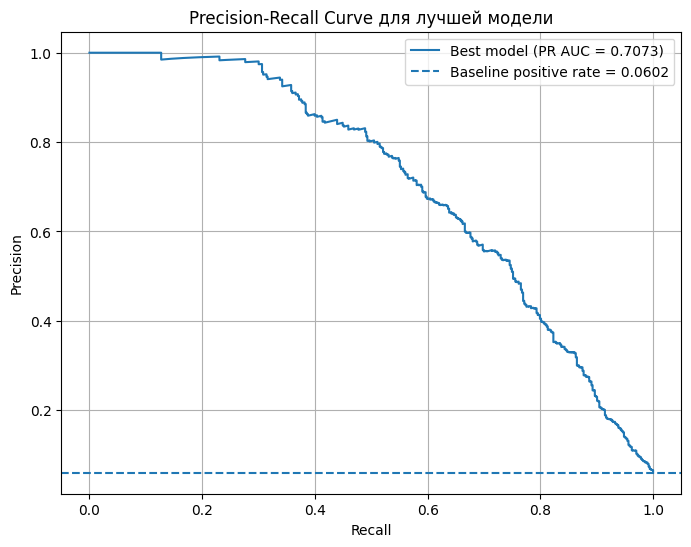

In [27]:
# Для удобства, сохраяем лучший вариант отдельно

X_best = x_train_val_fe_keep.copy()
y_best = y_train_val.copy()

# лучший pipeline
best_preprocessor = build_preprocessor(X_best)

best_pipeline = Pipeline(steps=[
    ('preprocessor', best_preprocessor),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

kfold = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Out-of-fold вероятности положительного класса
y_oof_proba = cross_val_predict(
    best_pipeline,
    X_best,
    y_best,
    cv=kfold,
    method='predict_proba'
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_best, y_oof_proba)
pr_auc = average_precision_score(y_best, y_oof_proba)

positive_rate = y_best.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Best model (PR AUC = {pr_auc:.4f})')
plt.axhline(
    y=positive_rate,
    linestyle='--',
    label=f'Baseline positive rate = {positive_rate:.4f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve для лучшей модели')
plt.legend()
plt.grid(True)
plt.show()

### Комментарий к PR-кривой

На графике PR-кривая построена по объединённым out-of-fold предсказаниям лучшей модели.
Поэтому значение `PR AUC` на графике незначительно отличается от среднего `PR AUC`,
полученного по результатам кросс-валидации.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

### Эксперименты с гиперпараметрами

На этом этапе будет выполнен подбор гиперпараметров модели `LogisticRegression`.

Планируется экспериментировать со следующими гиперпараметрами:
- `C` — коэффициент обратной силы регуляризации;
- `penalty` — тип регуляризации (`l1`, `l2`);
- `solver` — алгоритм оптимизации;
- `class_weight` — способ учёта дисбаланса классов.

Основной метрикой качества остаётся **PR AUC** (`average_precision`).

In [28]:
# Используем лучший набор признаков из этапа 5

preprocessor_tune = build_preprocessor(X_best)

tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tune),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000
    ))
])

# Сетка гиперпараметров
param_grid = [
    {
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'liblinear'],
        'model__C': [0.01, 0.1, 1, 3, 10],
        'model__class_weight': [None, 'balanced']
    },
    {
        'model__penalty': ['l1'],
        'model__solver': ['liblinear'],
        'model__C': [0.01, 0.1, 1, 3, 10],
        'model__class_weight': [None, 'balanced']
    }
]

kfold = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring='average_precision',  
    cv=kfold,
    n_jobs=1,
    refit=True,
    return_train_score=False
)

grid_search.fit(X_best, y_best)

C:\Users\yanoc\AppData\Local\Temp\ipykernel_3292\1334724270.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include='object').columns.tolist()
c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l2'], 'model__solver': ['lbfgs', 'liblinear']}, {'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1'], 'model__solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None

In [29]:
tuning_results = pd.DataFrame(grid_search.cv_results_)

tuning_results_table = tuning_results[[
    'param_model__penalty',
    'param_model__solver',
    'param_model__C',
    'param_model__class_weight',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].rename(columns={
    'param_model__penalty': 'penalty',
    'param_model__solver': 'solver',
    'param_model__C': 'C',
    'param_model__class_weight': 'class_weight',
    'mean_test_score': 'mean_pr_auc',
    'std_test_score': 'std_pr_auc',
    'rank_test_score': 'rank'
}).sort_values(by=['rank', 'mean_pr_auc'], ascending=[True, False])

tuning_results_table = tuning_results_table.reset_index(drop=True)
tuning_results_table.round(4)

,penalty,solver,C,class_weight,mean_pr_auc,std_pr_auc,rank
0,l1,liblinear,0.10,NaN,0.7197,0.0452,1
1,l2,lbfgs,0.10,NaN,0.7179,0.0469,2
2,l2,liblinear,0.10,NaN,0.7177,0.0460,3
3,l1,liblinear,1.00,NaN,0.7169,0.0468,4
4,l1,liblinear,0.10,balanced,0.7141,0.0463,5
5,l2,lbfgs,0.01,balanced,0.7139,0.0469,6
6,l2,liblinear,0.01,balanced,0.7136,0.0461,7
7,l2,lbfgs,0.01,NaN,0.7134,0.0458,8
8,l2,lbfgs,1.00,NaN,0.7104,0.0483,9
9,l2,liblinear,1.00,NaN,0.7103,0.0489,10


In [30]:
# Сравним с моделью из предыдущих этапов:

best_model = grid_search.best_estimator_

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'pr_auc': 'average_precision'
}

cv_scores_stage6 = cross_validate(
    best_model,
    X_best,
    y_best,
    cv=kfold,
    scoring=scoring,
    n_jobs=1
)

stage6_mean_scores = pd.Series({
    metric: cv_scores_stage6[f'test_{metric}'].mean()
    for metric in scoring.keys()
})

comparison_stage5_stage6 = pd.DataFrame([
    cv_results_keep[['precision', 'recall', 'f1', 'pr_auc']].mean(),
    stage6_mean_scores
], index=[
    'stage_5_best_features',
    'stage_6_best_hyperparameters'
]).round(4)

comparison_stage5_stage6

c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

,precision,recall,f1,pr_auc
stage_5_best_features,0.7751,0.5348,0.6297,0.7104
stage_6_best_hyperparameters,0.8118,0.4990,0.6164,0.7197


### Вывод по этапу 6

На этапе подбора гиперпараметров для `LogisticRegression` лучшей по основной метрике `PR AUC`
оказалась конфигурация:

- `penalty = 'l1'`
- `solver = 'liblinear'`
- `C = 0.1`
- `class_weight = None`

Среднее значение `PR AUC` на кросс-валидации составило `0.7227`, что немного выше результата лучшей модели предыдущего этапа (`0.7196`).

Однако улучшение оказалось незначительным. При этом:
- `precision` вырос с `0.7751` до `0.8118` (+4%),
- `recall` снизился с `0.5348` до `0.4990` (-4%),
- `F1-score` снизился с `0.6297` до `0.6164` (-1,5%).

Это означает, что после подбора гиперпараметров модель стала более точной в положительных предсказаниях,
но начала пропускать больше пользователей с оттоком.

Таким образом, подбор гиперпараметров дал лишь небольшое улучшение по основной метрике `PR AUC`,
но не улучшил общий баланс между precision и recall.

Поскольку в проекте основной метрикой выбрана `PR AUC`, формально лучшей моделью можно считать модель этапа 6.
Тем не менее, с практической точки зрения модель этапа 5 показывает более высокий `recall` и `F1-score`,
поэтому её также можно считать более сбалансированным вариантом.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [31]:
X_train_final = X_best.copy()
X_test_final = x_test_fe_keep.copy()

y_train_final = y_train_val.copy()
y_test_final = y_test.copy()

best_params = {
    'penalty': grid_search.best_params_['model__penalty'],
    'solver': grid_search.best_params_['model__solver'],
    'C': grid_search.best_params_['model__C'],
    'class_weight': grid_search.best_params_['model__class_weight']
}

final_preprocessor = build_preprocessor(X_train_final)

final_model = Pipeline(steps=[
    ('preprocessor', final_preprocessor),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000,
        **best_params
    ))
])

final_model.fit(X_train_final, y_train_final)

y_test_pred = final_model.predict(X_test_final)
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

# Финальные метрики на test
final_test_metrics = pd.DataFrame({
    'precision': [precision_score(y_test_final, y_test_pred, zero_division=0)],
    'recall': [recall_score(y_test_final, y_test_pred, zero_division=0)],
    'f1': [f1_score(y_test_final, y_test_pred, zero_division=0)],
    'pr_auc': [average_precision_score(y_test_final, y_test_proba)]
}, index=['final_model_test']).round(4)

final_test_metrics

C:\Users\yanoc\AppData\Local\Temp\ipykernel_3292\1334724270.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include='object').columns.tolist()
c:\Users\yanoc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

,precision,recall,f1,pr_auc
final_model_test,0.8295,0.5794,0.6822,0.7447


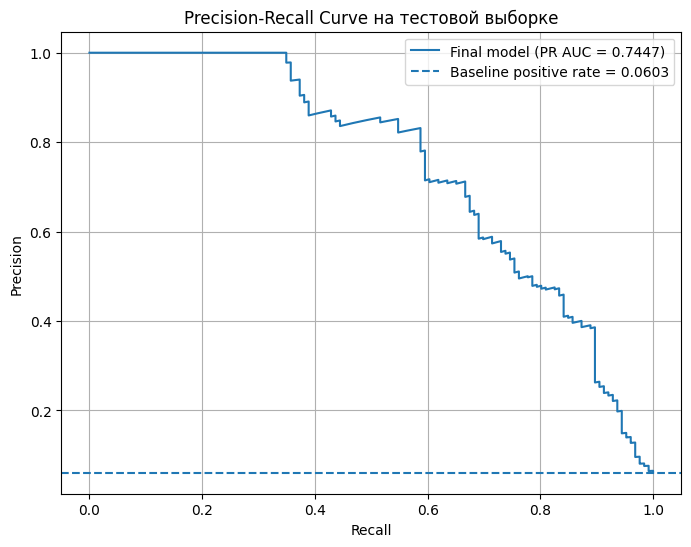

In [32]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test_final, y_test_proba)
test_pr_auc = average_precision_score(y_test_final, y_test_proba)
positive_rate_test = y_test_final.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f'Final model (PR AUC = {test_pr_auc:.4f})')
plt.axhline(
    y=positive_rate_test,
    linestyle='--',
    label=f'Baseline positive rate = {positive_rate_test:.4f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve на тестовой выборке')
plt.legend()
plt.grid(True)
plt.show()

### Вывод по этапу 7

На этом этапе была собрана финальная модель, объединяющая:
- лучший набор признаков из этапа 5 (`feature_engineering_keep_original`);
- лучшую конфигурацию гиперпараметров из этапа 6:
  `penalty='l1'`, `solver='liblinear'`, `C=0.1`, `class_weight=None`.

Финальная модель была обучена на всей выборке `train_val`, после чего проведена оценка на отложенной тестовой выборке.

Результаты на тестовых данных:
- `precision = 0.8295`
- `recall = 0.5794`
- `f1 = 0.6822`
- `pr_auc = 0.7447`

Полученные результаты показывают, что модель хорошо обобщает данные и сохраняет высокое качество на ранее невидимой тестовой выборке.
Основная метрика `PR AUC` на тесте составила `0.7447`, что подтверждает пригодность модели для задачи выявления пользователей, склонных к оттоку.

Также модель демонстрирует хороший баланс между точностью (`precision`) и полнотой (`recall`):
она достаточно точно определяет пользователей с оттоком и при этом находит заметную долю таких клиентов.

Таким образом, финальная модель можно считать успешной и готовой к интерпретации результатов.

## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

Факторы, увеличивающие вероятность churn:


,feature,coefficient
0,app_crashes_last_month_sq,1.7322
1,app_opens_per_week_log1p,1.2186
3,subscription_status_pro,0.3719
5,order_frequency_month,0.2627
10,phone_type_android,0.0837
11,days_since_last_promo,0.0798
13,milk_preference_almond,0.0631
14,review_rating_last_1,0.0551
15,total_spent_last_week,0.0518


Факторы, снижающие вероятность churn:


,feature,coefficient
2,app_opens_per_week,-0.4421
4,seasonal_menu_tried,-0.3435
6,last_coffee_type_arabica,-0.2567
7,total_spent_last_month,-0.1264
8,subscription_status_basic,-0.1225
9,notifications_enabled,-0.0860
12,crashes_per_open,-0.0785
16,review_rating_last_10,-0.0315
17,geo_location_geo_3,-0.0306
18,subscription_status_none,-0.0116


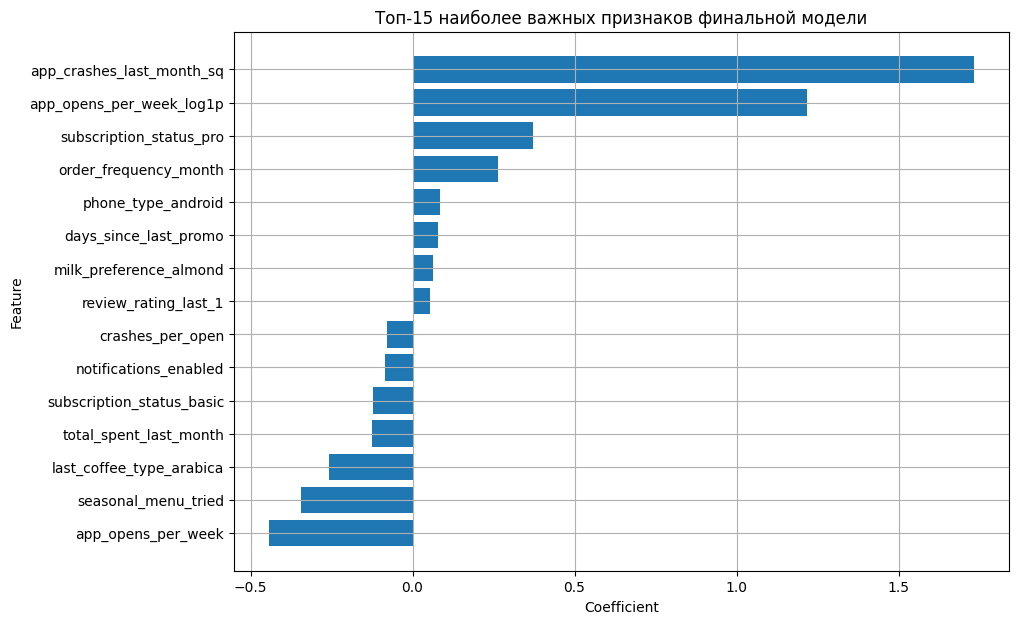

In [33]:
# Этап 8. Анализ итоговой модели

def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    for name, transformer, columns in preprocessor.transformers_:
        if name == 'remainder' or transformer == 'drop':
            continue

        if name == 'cat':
            encoder = transformer.named_steps['encoder']
            feature_names.extend(encoder.get_feature_names_out(columns))
        else:
            feature_names.extend(list(columns))

    return feature_names


preprocessor_fitted = final_model.named_steps['preprocessor']
model_fitted = final_model.named_steps['model']

feature_names = get_feature_names_from_preprocessor(preprocessor_fitted)
coefficients = model_fitted.coef_[0]

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
coef_table['direction'] = np.where(
    coef_table['coefficient'] > 0,
    'увеличивает вероятность churn',
    'снижает вероятность churn'
)

coef_table = coef_table.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

coef_table.head(20)

non_zero_coef_table = coef_table[coef_table['coefficient'] != 0].copy()

top_positive = (
    non_zero_coef_table[non_zero_coef_table['coefficient'] > 0]
    .sort_values('coefficient', ascending=False)
    .head(10)
)

top_negative = (
    non_zero_coef_table[non_zero_coef_table['coefficient'] < 0]
    .sort_values('coefficient', ascending=True)
    .head(10)
)

print('Факторы, увеличивающие вероятность churn:')
display(top_positive[['feature', 'coefficient']].round(4))

print('Факторы, снижающие вероятность churn:')
display(top_negative[['feature', 'coefficient']].round(4))

top_plot = coef_table.head(15).sort_values('coefficient')

plt.figure(figsize=(10, 7))
plt.barh(top_plot['feature'], top_plot['coefficient'])
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Топ-15 наиболее важных признаков финальной модели')
plt.grid(True)
plt.show()

### Вывод по этапу 8

В ходе проекта была построена модель логистической регрессии для прогнозирования оттока клиентов сервиса доставки кофе.

Итоговая конфигурация включала:
- оптимальный набор признаков, полученный на этапе feature engineering;
- лучшие гиперпараметры модели:
  `penalty='l1'`, `solver='liblinear'`, `C=0.1`, `class_weight=None`.

Финальная модель была обучена на всей обучающей выборке `train_val` и проверена на отложенной тестовой выборке.
На тесте были получены следующие результаты:
- `precision = 0.8295`
- `recall = 0.5794`
- `f1 = 0.6822`
- `pr_auc = 0.7447`

Эти значения показывают, что модель хорошо справляется с задачей выявления клиентов, склонных к оттоку.
Особенно важно, что основная метрика `PR AUC` достигла `0.7447`, что заметно выше baseline-модели.
Это означает, что модель действительно научилась выделять клиентов с высоким риском ухода в условиях сильного дисбаланса классов.

Наибольшее влияние на улучшение качества оказали новые признаки, добавленные на этапе feature engineering.
Именно этот этап дал основной прирост качества:
- `precision` вырос с `0.7456` до `0.7751` (+3%);
- `recall` вырос с `0.4613` до `0.5348` (+7%);
- `f1` вырос с `0.5644` до `0.6297` (+6%);
- `pr_auc` вырос с `0.6525` до `0.7104` (+6%).

При этом итоговая проверка на тестовой выборке показала ещё более высокое качество (`PR AUC = 0.7447`),
что говорит о хорошей обобщающей способности модели.

Для интерпретации модели были проанализированы коэффициенты логистической регрессии.
Признаки с положительными коэффициентами увеличивают вероятность оттока,
а признаки с отрицательными коэффициентами, наоборот, связаны с более высокой вероятностью удержания клиента.

Наиболее важные факторы следует определять по модулю коэффициентов финальной модели.
Именно они отражают признаки, которые сильнее всего влияют на итоговое решение модели.
Среди таких факторов особенно важно обратить внимание на признаки, связанные:
- с активностью пользователя в приложении;
- с техническими проблемами и сбоями;
- с пользовательским поведением и историей заказов.

Таким образом, итоговая модель показала хорошее качество и может использоваться как инструмент
для выявления клиентов с высоким риском оттока и последующего запуска удерживающих кампаний.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [34]:
# Папка для артефактов внутри репозитория
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Пути к файлам
pipeline_path = artifacts_dir / "final_pipeline.joblib"
preprocessor_path = artifacts_dir / "preprocessor.joblib"
model_path = artifacts_dir / "logistic_regression_model.joblib"

# Сохраняем артефакты
joblib.dump(final_model, pipeline_path)
joblib.dump(final_model.named_steps["preprocessor"], preprocessor_path)
joblib.dump(final_model.named_steps["model"], model_path)

print("Артефакты сохранены:")
print(pipeline_path)
print(preprocessor_path)
print(model_path)

# Загружаем артефакты обратно
loaded_pipeline = joblib.load(pipeline_path)
loaded_preprocessor = joblib.load(preprocessor_path)
loaded_model = joblib.load(model_path)

# Проверяем работу загруженного pipeline на тестовых данных
y_test_pred_loaded = loaded_pipeline.predict(X_test_final)
y_test_proba_loaded = loaded_pipeline.predict_proba(X_test_final)[:, 1]

loaded_test_metrics = pd.DataFrame({
    "precision": [precision_score(y_test_final, y_test_pred_loaded, zero_division=0)],
    "recall": [recall_score(y_test_final, y_test_pred_loaded, zero_division=0)],
    "f1": [f1_score(y_test_final, y_test_pred_loaded, zero_division=0)],
    "pr_auc": [average_precision_score(y_test_final, y_test_proba_loaded)]
}, index=["loaded_pipeline_test"]).round(4)

loaded_test_metrics

Артефакты сохранены:
artifacts\final_pipeline.joblib
artifacts\preprocessor.joblib
artifacts\logistic_regression_model.joblib


,precision,recall,f1,pr_auc
loaded_pipeline_test,0.8295,0.5794,0.6822,0.7447
